#**Demo for Machine Learning Process Report: Regression Problems**

**Excercise**

**Guidelines**

This case study is based on the famous Boston housing data. It contains the details of 506 houses in the Boston city.

Your task is to create a machine learning model which can predict the average price of house based on its characteristics.

In the below case study I will discuss the step by step approach to create a Machine Learning predictive model in such scenarios.

**You can use this flow as a template to solve any supervised ML Regression problem!**

**The flow (Key steps) of the case study is as below:**

1.  Reading the data in python and data description
2.  Defining the problem statement
3.  Looking at the distribution of Target variable
4.  Basic data exploration for rejecting useless columns
5.  Visual Exploratory Data Analysis for data distribution (Histogram and Barcharts) and feature selection based on data distribution
6.  Outlier treatment
7.  Missing Values treatment
8.  Feature selection by Visual correlation analysis and Statistical measurement
9.  Selecting final predictors for Machine Learning summary
10. Data Pre-processing for Machine Learning
11. Model construction
12. Results Analysis

I know its a long list!! Take a deep breath... and let us get started!

#**1. Reading the data into python and data description**


This is one of the most important steps in machine learning! You must understand the data and the domain well before trying to apply any machine learning algorithm.

The data has one file "BostonData.csv". This file contains 506 house details from the Boston city.

You can download the data required for this case study here:

https://thinkingneuron.com/wp-content/uploads/2020/09/BostonHousingData.csv

Data description
The business meaning of each column in the data is as below:

* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX - nitric oxides concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built prior to 1940
* DIS - weighted distances to five Boston employment centres
* RAD - index of accessibility to radial highways
* TAX - full-value property-tax rate per 10,000 dollars
* PTRATIO - pupil/teacher ratio by town
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT - % lower status of the population
* MEDV - Median value of owner-occupied homes in $1000's

In [ ]:
# Supressing the warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading the dataset
import pandas as pd
import numpy as np

BostonData=pd.read_csv('/content/drive/MyDrive/FRA 503  Machine Learning /Coding/Raw dataset/BostonHousingData.csv', encoding='latin')
print('Shape before deleting duplicate values:', BostonData.shape)

# Removing duplicate rows if any
BostonData=BostonData.drop_duplicates()
print('Shape After deleting duplicate values:', BostonData.shape)

# Printing sample data
# Start observing the Quantitative/Categorical/Qualitative variables
BostonData.head(10)

Shape before deleting duplicate values: (506, 14)
Shape After deleting duplicate values: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


#**2. Defining the problem statement**

Create a ML model which can predict the price( MEDV ) of a house

* **Target Variable:** MEDV
* **Predictors:** CRIM, ZN, INDUS, CHAS, NOX, RM, etc.
* **Samples:**  Houses in the Boston city

**Determining the type of Machine Learning Problems**

Based on the problem statement you can understand that we need to create a **supervised ML Regression model**, as the target variable is Continuous.

**Note:** If you have assumptions for designing Target Variables and Predictors, you can be further explained in this section.

#**3. Looking at the distribution of Target**



**Guidelines**
* If target variable's distribution is too skewed then the predictive modeling will not be possible.
* Bell curve is desirable but slightly positive skew or negative skew is also fine
* When performing Regression, make sure the histogram looks like a bell curve or slight skewed version of it. Otherwise it impacts the Machine Learning algorithms ability to learn all the scenarios.
* If there is too much skewness, then outlier treatment should be done

In [ ]:
BostonData['MEDV']

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
BostonData['MEDV'].describe()

,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


Median of MEDV: 21.2


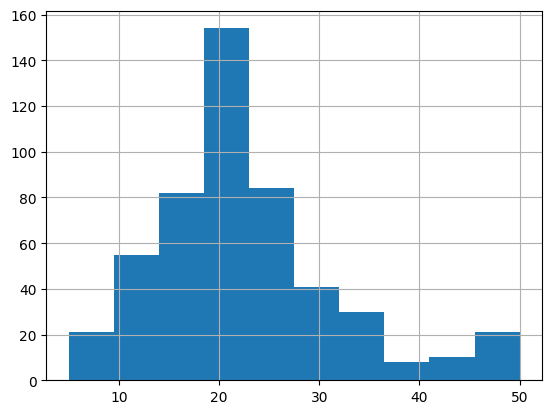

In [ ]:
# Creating histogram as the Target variable is Continuous
# This will help us to understand the distribution of the MEDV values
BostonData['MEDV'].hist()
BostonData['MEDV'].describe()
median_value = BostonData['MEDV'].median()
print("Median of MEDV:", median_value)

The data distribution of the target variable is satisfactory to proceed further. There are sufficient number of rows for each type of values to learn from. From the histogram there is a mean value which is 22.532806 20. There is no outliers

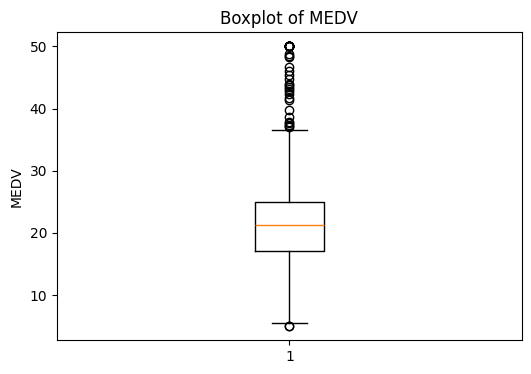

In [ ]:
import matplotlib.pyplot as plt

# Boxplot ของตัวแปรเป้าหมาย MEDV
plt.figure(figsize=(6,4))
plt.boxplot(BostonData['MEDV'])
plt.title('Boxplot of MEDV')
plt.ylabel('MEDV')
plt.show()

#**4. Basic data exploration**



**Guidelines**

This step is performed to guage the overall data. The volume of data, the types of columns present in the data. Initial assessment of the data should be done to identify which columns are **Quantitative, Categorical or Qualitative**.

This step helps to start the column rejection process. You must look at each column carefully and ask, does this column affect the values of the Target variable? For example in this case study, you will ask, **does this column affect the price of the house?** If the answer is a clear "No", then remove the column immediately from the data, otherwise keep the column for further analysis.

There are four commands which are used for Basic data exploration in Python

* head() : This helps to see a few sample rows of the data
* info() : This provides the summarized information of the data
* describe() : This provides the descriptive statistical details of the data
* nunique(): This helps us to identify if a column is categorical or continuous

In [ ]:
# Looking at sample rows in the data
BostonData.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Observing the summarized information of data
# Data types, Missing values based on number of non-null values Vs total rows etc.
# Remove those variables from data which have too many missing values (Missing Values > 30%)
# Remove Qualitative variables which cannot be used in Machine Learning
BostonData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
# Looking at the descriptive statistics of the data
BostonData.describe(include='all')

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
# Finging unique values for each column
# TO understand which column is categorical and which one is Continuous
# Typically if the numer of unique values are < 20 then the variable is likely to be a category otherwise continuous
BostonData.nunique()

,0
CRIM,504
ZN,26
INDUS,76
CHAS,2
NOX,81
RM,446
AGE,356
DIS,412
RAD,9
TAX,66


**Data Exploration Results**

Based on the basic exploration above, you can now create a simple report of the data, noting down your observations regaring each column. Hence, creating a initial roadmap for further analysis.

The selected columns in this step are not final, further study will be done and then a final list will be created

* CRIM - Continuous(numeric). Selected.
* ZN - Continuous(numeric). Selected.
* INDUS - Continuous(numeric). Selected.
* CHAS - Categorical(norminal). Selected.
* NOX - Continuous(numeric). Selected.
* RM - Continuous(numeric). Selected.
* AGE - Continuous(numeric). Selected.
* DIS - Continuous(numeric). Selected.
* RAD - Categorical(ordinal). Selected.
* TAX - Continuous(numeric). Selected.
* PTRATIO - Continuous(numeric). Selected.
* B - Continuous(numeric). Selected.
* LSTAT - Continuous(numeric). Selected.
* MEDV - Continuous(numeric). Selected. This is the **Target Variable!**

**Summary:** No removing useless columns from the data.

# **5.Visual Exploratory Data Analysis for data distribution (Histogram and Barcharts) and feature selection based on data distribution**



**Guidelines**
* Categorical variables: Barplot
* Continuous variables: Histogram and Boxplot

## **5.1. Visualize distribution of all the Categorical Predictor variables in the data using bar plots**

We can spot a categorical variable in the data by looking at the unique values in them. Typically a categorical variable contains less than 20 Unique values AND there is repetition of values, which means the data can be grouped by those unique values.

Based on the Basic Data Exploration above, we have spotted two categorical predictors in the data

**Categorical Predictors:**

'CHAS', 'RAD'

We use bar charts to see how the data is distributed for these categorical columns.

In [ ]:
# Plotting multiple bar charts at once for categorical variables
# Since there is no default function which can plot bar charts for multiple columns at once
# we are defining our own function for the same

def PlotBarCharts(inpData, colsToPlot):
    %matplotlib inline

    import matplotlib.pyplot as plt

    # Generating multiple subplots
    fig, subPlot=plt.subplots(nrows=1, ncols=len(colsToPlot), figsize=(10,3))
    fig.suptitle('Bar charts of: '+ str(colsToPlot))

    for colName, plotNumber in zip(colsToPlot, range(len(colsToPlot))):
        inpData.groupby(colName).size().plot(kind='bar',ax=subPlot[plotNumber])

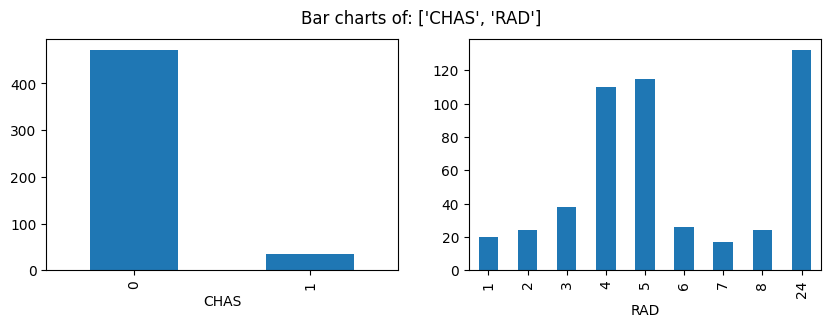

In [ ]:
# Calling the function
PlotBarCharts(inpData=BostonData, colsToPlot=['CHAS','RAD'])

### **Bar Charts Interpretation**

**Guidelines**

These bar charts represent the frequencies of each category in the Y-axis and the category names in the X-axis.

In the ideal bar chart each category has comparable frequency. Hence, there are enough rows for each category in the data for the ML algorithm to learn.

If there is a column which shows too skewed distribution where there is only one dominant bar and the other categories are present in very low numbers. These kind of columns may not be very helpful in machine learning. We confirm this in the correlation analysis section and take a final call to select or reject the column.

***********************************************************

**Interpretation**

In this data, "CHAS" is skewed. There is just one bar which is dominating and other one have very less rows. Such columns may not be correlated with the target variable because there is no information to learn. The algorithms cannot find any rule like when the value is this then the target variable is that.

Whenever in doubt, always investigate the column further.

**Selected Categorical Variables:** Both the categorical variables are selected for further analysis.
* **'CHAS':** Selected **(Doubt)**
* **'RAD':** Selected

## **5.2. Visualize distribution of all the Continuous Predictor variables in the data using histograms**

Based on the Basic Data Exploration, there are eleven continuous predictor variables 'CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', and 'LSTAT'.

array([[<Axes: title={'center': 'CRIM'}>, <Axes: title={'center': 'ZN'}>,
        <Axes: title={'center': 'INDUS'}>],
       [<Axes: title={'center': 'NOX'}>, <Axes: title={'center': 'RM'}>,
        <Axes: title={'center': 'AGE'}>],
       [<Axes: title={'center': 'DIS'}>, <Axes: title={'center': 'TAX'}>,
        <Axes: title={'center': 'PTRATIO'}>],
       [<Axes: title={'center': 'B'}>, <Axes: title={'center': 'LSTAT'}>,
        <Axes: >]], dtype=object)

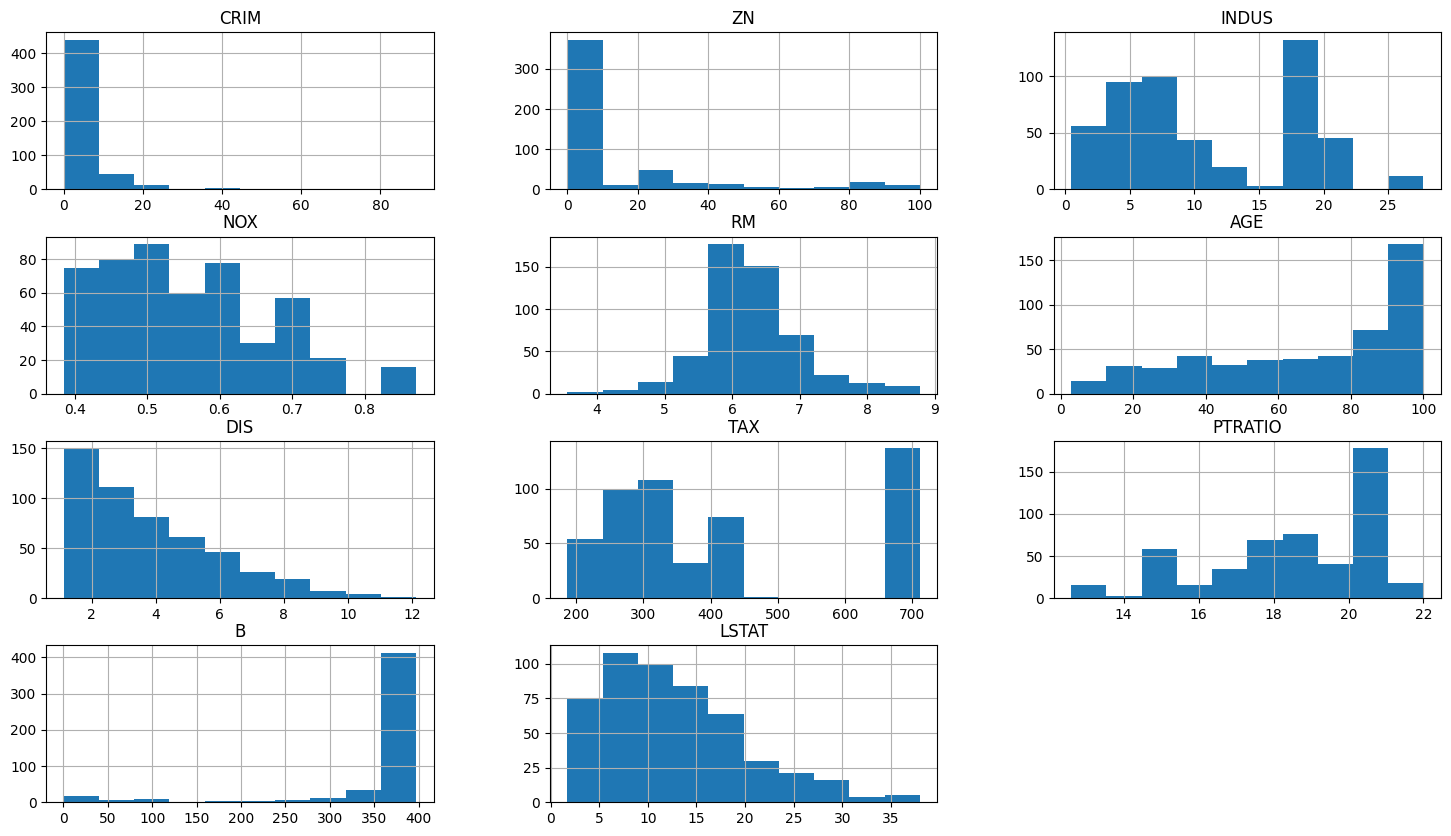

In [ ]:
# Plotting histograms of multiple columns together
BostonData.hist(['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
                 'PTRATIO', 'B', 'LSTAT'], figsize=(18,10))

<Axes: >

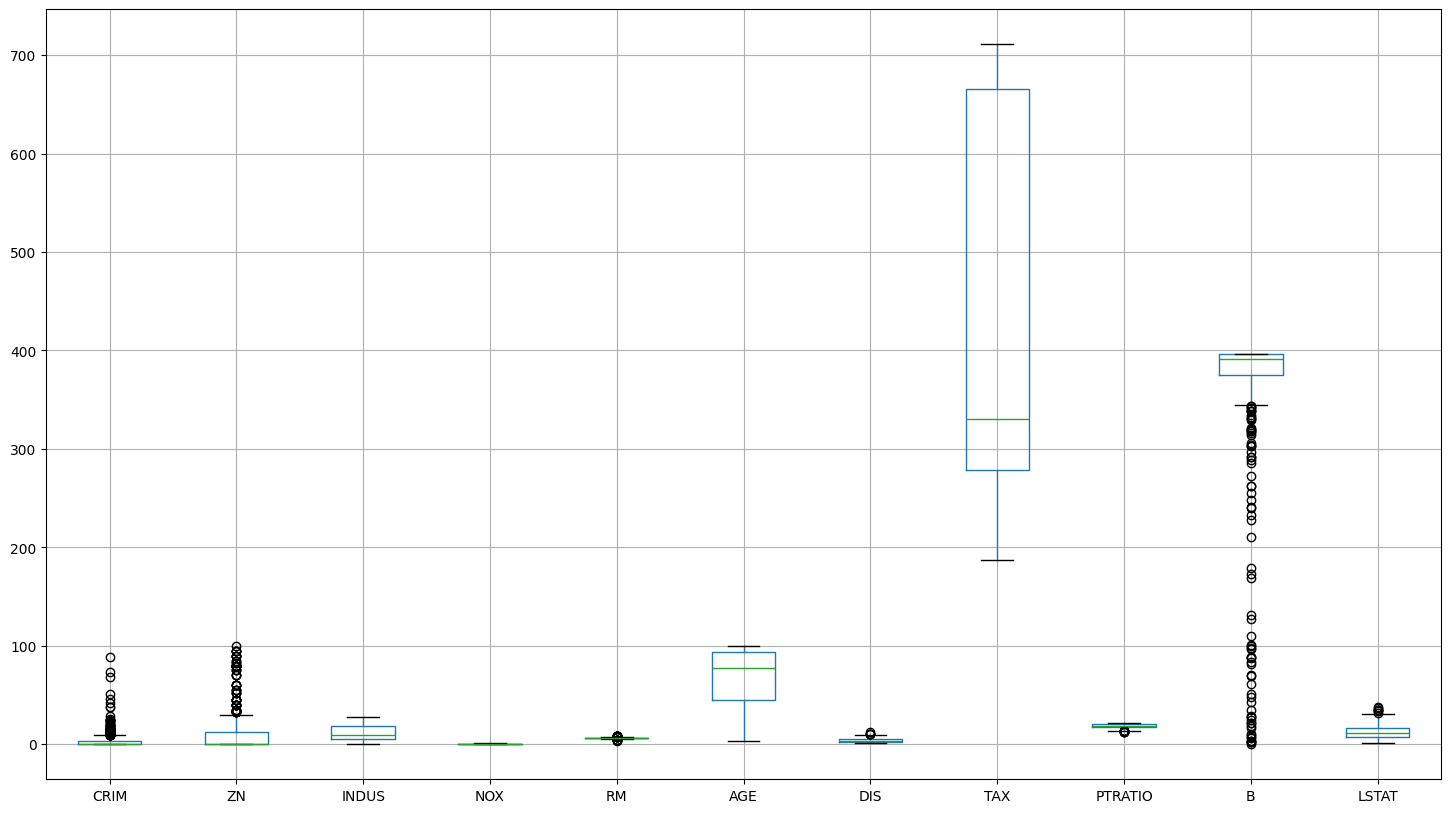

In [ ]:
# Plotting boxplot of multiple columns together to find distribution and outliers
BostonData.boxplot(['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
                 'PTRATIO', 'B', 'LSTAT'], figsize=(18,10))

<Axes: >

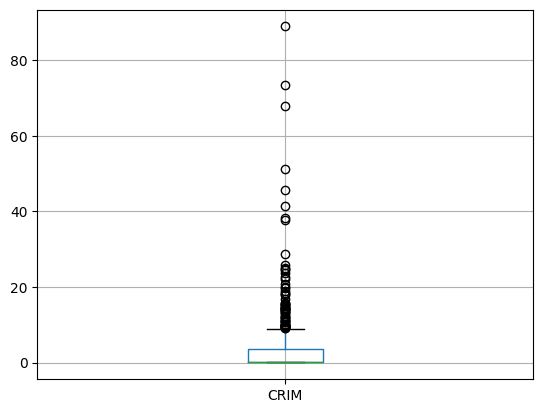

In [ ]:
BostonData.boxplot(['CRIM'])

### **Histogram Interpretation**

**Guidelines**
Histograms shows us the data distribution for a single continuous variable.

The X-axis shows the range of values and Y-axis represent the number of values in that range. For example, in the above histogram of "AGE", there are around 200 rows in data that has age value between 90 to 100.

The ideal outcome for histogram is a bell curve or slightly skewed bell curve. If there is too much skewness, then outlier treatment should be done and the column should be re-examined, if that also does not solve the problem then only reject the column.

***********************************************************

**Interpretation**

**Selected Continuous Variables:**

* **CRIM :** Selected. Strongly positive skewed distribution, acceptable. Outliers seen beyond 40, need to treat them.
* **ZN :** Selected. Strongly positive skewed distribution, acceptable. Outliers seen, need to treat them.
* **INDUS :** Selected. The distribution is good (Bimodal distribution).
* **NOX :** Selected. Slightly positive skewed distribution, acceptable.
* **RM :** Selected. The distribution is good. (Normal)
* **AGE :** Selected. Slightly negative skewed distribution, acceptable.
* **DIS :** Selected. Slightly positive skewed distribution, acceptable.
* **TAX :** Selected. The distribution is good (Bimodal distribution).
* **PTRATIO :** Selected. Slightly negative skewed distribution, acceptable.
* **B:** Selected. Strongly positive skewed distribution, acceptable. Outliers seen, need to treat them or Bimodal distribution **(Doubt)**
* **LSTAT:** Selected. lightly positive skewed distribution, acceptable.

# **6. Outlier treatment**



**Guidelines**

Outliers are extreme values in the data which are far away from most of the values. You can see them as the tails in the histogram.

Outlier must be treated one column at a time. As the treatment will be slightly different for each column.

**Why I should treat the outliers?**

Outliers bias the training of machine learning models. As the algorithm tries to fit the extreme value, it goes away from majority of the data.

There are below two options to treat outliers in the data.

* **Option-1:** Delete the outlier Records. Only if there are just few rows lost.
* **Option-2**: Impute the outlier values with a logical business value
* **Option-3**: Replace outliers by looking at the histogram and boxplot

Below we are finding out the most logical value to be replaced in place of outliers by looking at the histogram.

**Replacing outliers for 'CRIM'**

In [ ]:
# Finding nearest values from 40
BostonData['CRIM'][BostonData['CRIM']<45].sort_values(ascending=False)

,CRIM
404,41.52920
398,38.35180
427,37.66190
413,28.65580
417,25.94060
...,...
55,0.01311
341,0.01301
285,0.01096
284,0.00906


Above result shows the nearest logical value is  41.52920, hence, replacing any value above 40 with it.

In [ ]:
# Replacing outliers with nearest possibe value
BostonData['CRIM'][BostonData['CRIM']>40] =  41.52920

**Visualizing distribution after outlier treatment**

The distribution has improved after the outlier treatment. There is still a tail but it is thick, that means there are many values in that range, hence, it is acceptable.

array([[<Axes: title={'center': 'CRIM'}>]], dtype=object)

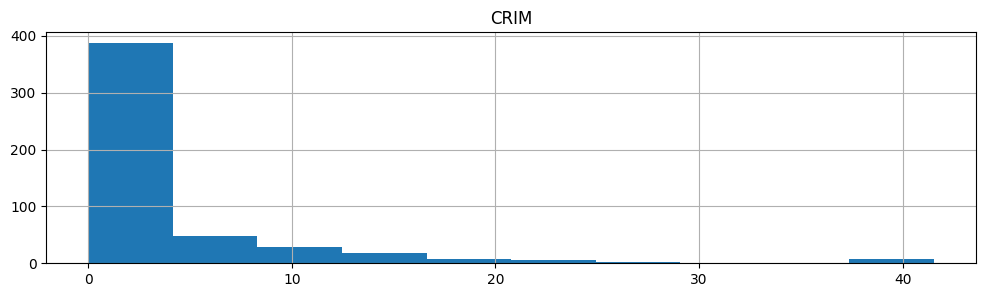

In [ ]:
BostonData.hist(['CRIM'], figsize=(12,3))

<Axes: >

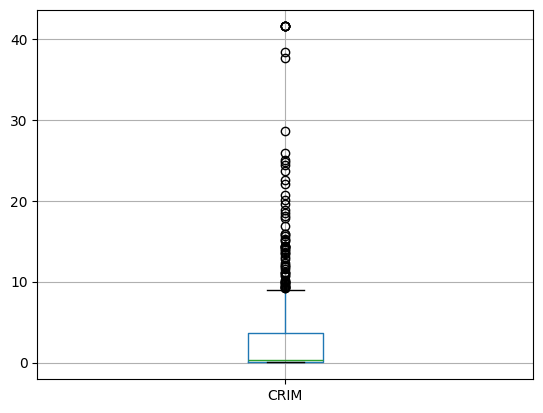

In [ ]:
BostonData.boxplot(['CRIM'])

# **7. Missing values treatment**



**Guidelines**

Missing values are treated for each column separately.

If a column has more than 30% data missing, then missing value treatment cannot be done. That column must be rejected because too much information is missing.

There are below options for treating missing values in data.

* Delete the missing value rows if there are only few records
* Impute the missing values with MEAN or MEDIAN value for continuous variables
* Impute the missing values with MODE value for categorical variables
* Interpolate the values based on nearby values
* Interpolate the values based on business logic

In [ ]:
# Finding how many missing values are there for each column
BostonData.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


No missing values in this data!!

# **8. Feature selection by Visual correlation analysis and Statistical measurement**



**Guidelines**

Now its time to finally choose the best columns(Features) which are correlated to the Target variable. This can be done directly by measuring the correlation values or ANOVA/Chi-Square tests. However, it is always helpful to visualize the relation between the Target variable and each of the predictors to get a better sense of data.

I have listed below the techniques used for visualizing relationship between two variables as well as measuring the strength statistically.

## **Visual exploration of relationship between variables**
* Continuous Vs Continuous ---- Scatter Plot
* Categorical Vs Continuous---- Box Plot
* Categorical Vs Categorical---- Grouped Bar Plots or Stacked Bar Plot

## **Statistical measurement of relationship strength between variables**
* Continuous Vs Continuous ---- Correlation matrix or Mutual information
* Categorical Vs Continuous---- ANOVA test or Mutual information
* Categorical Vs Categorical--- Chi-Square test or Mutual information

************************************************

In this case study the Target variable is Continuous, hence below two scenarios will be present

* Continuous Target Variable Vs Continuous Predictor
* Continuous Target Variable Vs Categorical Predictor

**Note:** In the case of choose the best features on predictor which are correlated with each other, you can do the same way of this step (optional).

## **8.1 Relationship exploration: Continuous Vs Continuous -- Scatter Charts**





### **8.1.1 Visual exploration**

When the Target variable is continuous and the predictor is also continuous, we can visualize the relationship between the two variables using scatter plot and measure the strength of relation using pearson's correlation value.

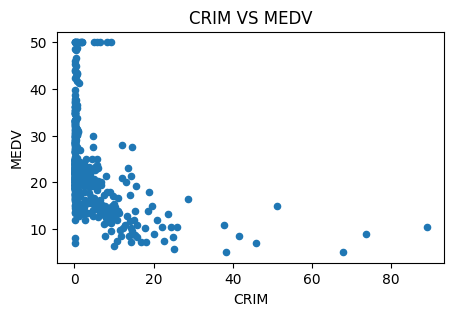

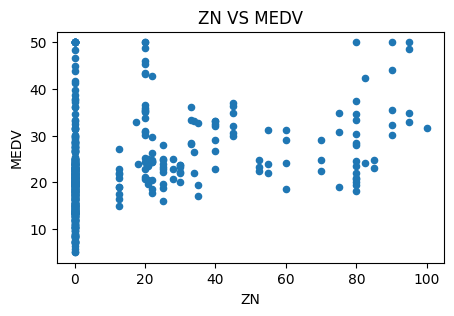

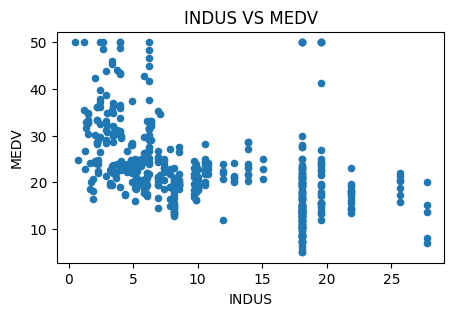

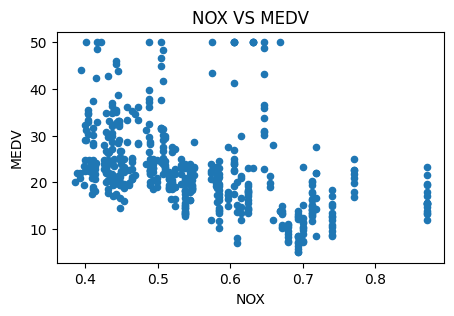

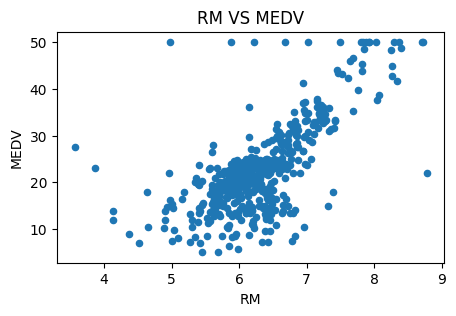

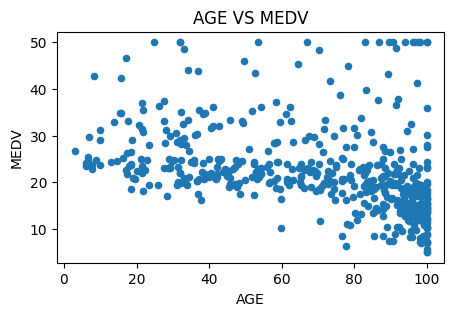

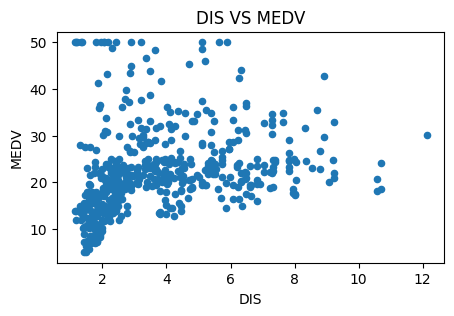

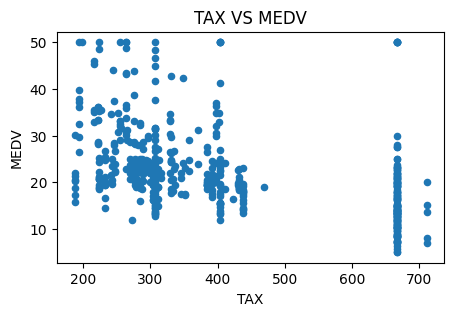

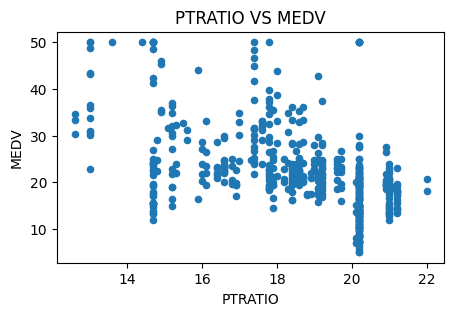

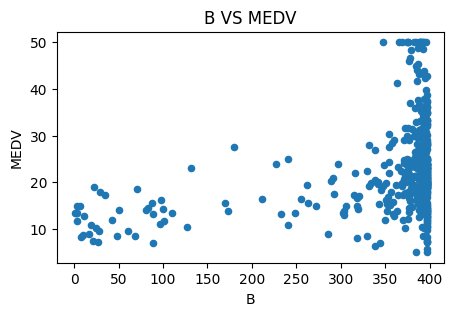

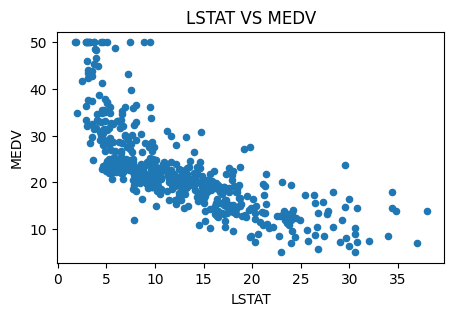

In [ ]:
ContinuousCols=['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
                 'PTRATIO', 'B', 'LSTAT']

# Plotting scatter chart for each predictor vs the target variable
for predictor in ContinuousCols:
    BostonData.plot.scatter(x=predictor, y='MEDV', figsize=(5,3), title=predictor+" VS "+ 'MEDV')

####**Scatter charts interpretation**

**Guidelines**

What should you look for in these scatter charts?

Trend. You should try to see if there is a visible trend or not. There could be three scenarios

* Increasing Trend: This means both variables are positively correlated. In simpler terms, they are directly proportional to each other, if one value increases, other also increases. This is good for ML!
* Decreasing Trend: This means both variables are negatively correlated. In simpler terms, they are inversely proportional to each other, if one value increases, other decreases. This is also good for ML!
* No Trend: You cannot see any clear increasing or decreasing trend. This means there is no correlation between the variables. Hence the predictor cannot be used for ML.

Based on this chart you can get a good idea about the predictor, if it will be useful or not. You confirm this by looking at the correlation value.

***********************************************************

**Interpretation**

**Selected Continuous Variables:**

* **CRIM :** Selected. Weakly decreasing Trend **(Doubt)**.
* **ZN :** Selected. Weakly increasing Trend **(Doubt)**.
* **INDUS :** Selected. Weakly decreasing Trend **(Doubt)**.
* **NOX :** Not selected. No Trend
* **RM :** Selected. Strongly increasing Trend.
* **AGE :** Not selected. No Trend
* **DIS :** Selected.  Weakly increasing Trend **(Doubt)**.
* **TAX :** Selected. Weakly decreasing Trend **(Doubt)**.
* **PTRATIO :** Selected. Weakly decreasing Trend **(Doubt)**.
* **B:** Selected. Weakly increasing Trend **(Doubt)**.
* **LSTAT:** Selected. Strongly decreasing Trend.

### **8.1.2 Statistical Feature Selection**

**Guidelines**

Pearson's correlation coefficient can simply be calculated as the covariance between two features x and y (numerator) divided by the product of their standard deviations(denominator).

* This value can be calculated only between two numeric columns
* Correlation between [-1,0) means inversely proportional, the scatter plot will show a downward trend
* Correlation between (0,1] means directly proportional, the scatter plot will show a upward trend
* Correlation near {0} means No relationship, the scatter plot will show no clear trend.
* If Correlation value between two variables is > 0.5 in magnitude, it indicates good relationship the sign does not matter
* We observe the correlations between Target variable and all other predictor variables(s) to check which columns/features/predictors are actually related to the target variable in question

In [ ]:
# Calculating correlation matrix
ContinuousCols=['MEDV','CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
                 'PTRATIO', 'B', 'LSTAT']

# Creating the correlation matrix
CorrelationData=BostonData[ContinuousCols].corr()
CorrelationData

,MEDV,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT
MEDV,1.000000,-0.432428,0.360445,-0.483725,-0.427321,0.695360,-0.376955,0.249929,-0.468536,-0.507787,0.333461,-0.737663
CRIM,-0.432428,1.000000,-0.232519,0.470668,0.488401,-0.269919,0.404162,-0.435133,0.672063,0.332839,-0.438657,0.533450
ZN,0.360445,-0.232519,1.000000,-0.533828,-0.516604,0.311991,-0.569537,0.664408,-0.314563,-0.391679,0.175520,-0.412995
INDUS,-0.483725,0.470668,-0.533828,1.000000,0.763651,-0.391676,0.644779,-0.708027,0.720760,0.383248,-0.356977,0.603800
NOX,-0.427321,0.488401,-0.516604,0.763651,1.000000,-0.302188,0.731470,-0.769230,0.668023,0.188933,-0.380051,0.590879
RM,0.695360,-0.269919,0.311991,-0.391676,-0.302188,1.000000,-0.240265,0.205246,-0.292048,-0.355501,0.128069,-0.613808
AGE,-0.376955,0.404162,-0.569537,0.644779,0.731470,-0.240265,1.000000,-0.747881,0.506456,0.261515,-0.273534,0.602339
DIS,0.249929,-0.435133,0.664408,-0.708027,-0.769230,0.205246,-0.747881,1.000000,-0.534432,-0.232471,0.291512,-0.496996
TAX,-0.468536,0.672063,-0.314563,0.720760,0.668023,-0.292048,0.506456,-0.534432,1.000000,0.460853,-0.441808,0.543993
PTRATIO,-0.507787,0.332839,-0.391679,0.383248,0.188933,-0.355501,0.261515,-0.232471,0.460853,1.000000,-0.177383,0.374044


In [ ]:
# Filtering only those columns where absolute correlation > 0.5 with Target Variable
# reduce the 0.5 threshold if no variable is selected
CorrelationData['MEDV'][abs(CorrelationData['MEDV']) > 0.5 ]

,MEDV
MEDV,1.000000
RM,0.695360
PTRATIO,-0.507787
LSTAT,-0.737663


**Final selected Continuous columns from Visual exploration and Statistical Feature Selection:**

'RM', 'PTRATIO','LSTAT'

## **8.2 Relationship exploration: Categorical Vs Continuous -- Box Plots**


### **8.2.1 Visual exploration**

When the target variable is Continuous and the predictor variable is Categorical we analyze the relation using Boxplots and measure the strength of relation using Anova test.

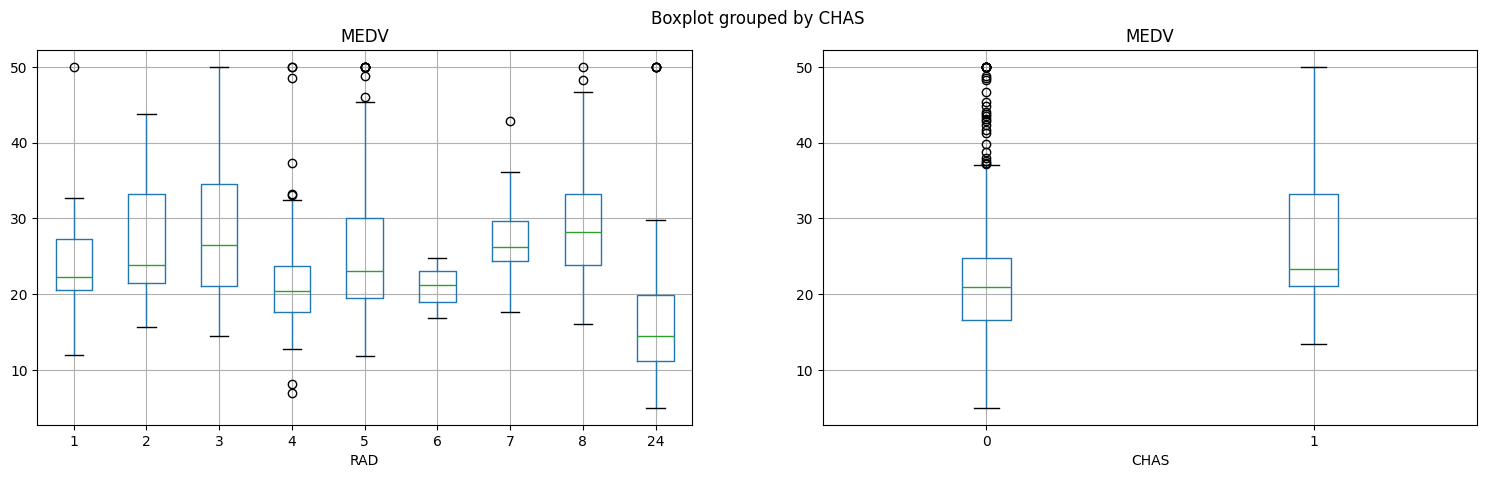

In [ ]:
# Box plots for continuous Target Variable "MEDV" and Categorical predictors
CategoricalColsList=['RAD', 'CHAS']

import matplotlib.pyplot as plt
fig, PlotCanvas=plt.subplots(nrows=1, ncols=len(CategoricalColsList), figsize=(18,5))

# Creating box plots for each continuous predictor against the Target Variable "MEDV"
for PredictorCol , i in zip(CategoricalColsList, range(len(CategoricalColsList))):
    BostonData.boxplot(column='MEDV', by=PredictorCol, figsize=(5,5), vert=True, ax=PlotCanvas[i])

#### **Box-Plots interpretation**

**Guidelines**

**What should you look for in these box plots?**

These plots gives an idea about the data distribution of continuous predictor in the Y-axis for each of the category in the X-Axis.

If the distribution looks similar for each category(Boxes are in the same line), that means the the continuous variable has NO effect on the target variable. Hence, the variables are not correlated to each other.

On the other hand if the distribution is different for each category(the boxes are not in same line!). It hints that these variables might be correlated with MEDV.

*****************************************
**interpretation**

In this data, both the categorical predictors looks correlated with the Target variable.

**Selected Categorical Variables:**

* **RAD :** Selected. The boxes are NOT in the same line especially in RAD = 24.
* **CHAS :** Selected. The boxes are closly in the same line. **(Doubt)**


### **8.2.2 Statistical Feature Selection**

**Guidelines**

Analysis of variance(ANOVA) is performed to check if there is any relationship between the given continuous and categorical variable

* Assumption(H0): There is NO relation between the given variables (i.e. The average(mean) values of the numeric Target variable is same for all the groups in the categorical Predictor variable)
* If the ANOVA P-Value is <0.05, that means we reject H0

In [ ]:
# Defining a function to find the statistical relationship with all the categorical variables
def FunctionAnova(inpData, TargetVariable, CategoricalPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### ANOVA Results ##### \n')
    for predictor in CategoricalPredictorList:
        CategoryGroupLists=inpData.groupby(predictor)[TargetVariable].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)

        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return(SelectedPredictors)

In [ ]:
# Calling the function to check which categorical variables are correlated with target
CategoricalPredictorList=['RAD', 'CHAS']
FunctionAnova(inpData=BostonData,
              TargetVariable='MEDV',
              CategoricalPredictorList=CategoricalPredictorList)

##### ANOVA Results ##### 

RAD is correlated with MEDV | P-Value: 3.1256493316010175e-24
CHAS is correlated with MEDV | P-Value: 7.390623170520815e-05


['RAD', 'CHAS']

The results of ANOVA confirm our visual analysis using box plots above.

All categorical variables are correlated with the Target variable. This is something we guessed by looking at the box plots!

**Final selected Categorical columns from Visual exploration and Statistical Feature Selection:**

'RAD', 'CHAS'

# **9. Selecting final predictors for Machine Learning summary**

Based on the above tests, selecting the final columns for machine learning

In [ ]:
SelectedColumns=['RM', 'PTRATIO','LSTAT', 'RAD', 'CHAS']

# Selecting final columns
DataForML=BostonData[SelectedColumns]
DataForML.head()

,RM,PTRATIO,LSTAT,RAD,CHAS
0,6.575,15.3,4.98,1,0
1,6.421,17.8,9.14,2,0
2,7.185,17.8,4.03,2,0
3,6.998,18.7,2.94,3,0
4,7.147,18.7,5.33,3,0


**Note:** If you still have a large number of features, you can use feature extraction to reduce the feature dimension like PCA (optional) or do in data preprocessing steps.

# **10. Data Pre-processing for Machine Learning**



**Guidelines**

List of steps performed on predictor variables before data can be used for machine learning

1. Converting each Ordinal Categorical columns to numeric
2. Converting Binary nominal Categorical columns to numeric using 1/0 mapping
3. Converting all other nominal categorical columns to numeric using pd.get_dummies()
4. Data Transformation (Optional): Standardization/Normalization/log/sqrt. Recommend if you are using distance based algorithms like KNN, or Neural Networks




## **10.1 Converting the ordinal variable to numeric**
In this data there is no Ordinal categorical variable in string format in this data.

## **10.2 Converting the binary nominal variable to numeric using 1/0 mapping**

There is no binary nominal variable in string format in this data

## **10.3 Converting the nominal variable to numeric using get_dummies()**
There is no nominal variable in string format to numeric using get_dummies()

In [ ]:
# Treating all the nominal variables at once using dummy variables
# DataForML_Numeric=pd.get_dummies(DataForML)
DataForML_Numeric=DataForML

# Adding Target Variable to the data
DataForML_Numeric['MEDV']=BostonData['MEDV']

# Printing sample rows
DataForML_Numeric.head()

,RM,PTRATIO,LSTAT,RAD,CHAS,MEDV
0,6.575,15.3,4.98,1,0,24.0
1,6.421,17.8,9.14,2,0,21.6
2,7.185,17.8,4.03,2,0,34.7
3,6.998,18.7,2.94,3,0,33.4
4,7.147,18.7,5.33,3,0,36.2


## **10.4 Data Transformation**

In [ ]:
# Separate Target Variable and Predictor Variables
TargetVariable='MEDV'
Predictors=['RM', 'PTRATIO', 'LSTAT', 'RAD', 'CHAS']

X=DataForML_Numeric[Predictors].values
y=DataForML_Numeric[TargetVariable].values

In [ ]:
X

array([[ 6.575, 15.3  ,  4.98 ,  1.   ,  0.   ],
       [ 6.421, 17.8  ,  9.14 ,  2.   ,  0.   ],
       [ 7.185, 17.8  ,  4.03 ,  2.   ,  0.   ],
       ...,
       [ 6.976, 21.   ,  5.64 ,  1.   ,  0.   ],
       [ 6.794, 21.   ,  6.48 ,  1.   ,  0.   ],
       [ 6.03 , 21.   ,  7.88 ,  1.   ,  0.   ]])

In [ ]:
y

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

**Standardization/Normalization of data**

You can choose not to run this step if you want to compare the resultant accuracy of this transformation with the accuracy of raw data.

However, if you are using KNN or Neural Networks, then this step should be recommended.

In [ ]:
### Sandardization of data ###
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Choose either standardization or Normalization
# On this data Min Max Normalization produced better results

# Choose between standardization and MinMAx normalization
#PredictorScaler=StandardScaler()
PredictorScaler=MinMaxScaler()

# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X)

In [ ]:
PredictorScalerFit

MinMaxScaler()

In [ ]:
# Generating the standardized values of X
X=PredictorScalerFit.transform(X)
X

array([[0.57750527, 0.28723404, 0.08967991, 0.        , 0.        ],
       [0.5479977 , 0.55319149, 0.2044702 , 0.04347826, 0.        ],
       [0.6943859 , 0.55319149, 0.06346578, 0.04347826, 0.        ],
       ...,
       [0.65433991, 0.89361702, 0.10789183, 0.        , 0.        ],
       [0.61946733, 0.89361702, 0.13107064, 0.        , 0.        ],
       [0.47307913, 0.89361702, 0.16970199, 0.        , 0.        ]])

**Splitting the data into Training and Testing sample**

We do not use the full data for creating the model. Some data is randomly selected and kept aside for checking how good the model is. This is known as Testing Data and the remaining data is called Training data on which the model is built. Typically 70% of data is used as Training data and the rest 30% is used as Tesing data.

In [ ]:
# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Sanity check for the sampled data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(354, 5)
(354,)
(152, 5)
(152,)


In [ ]:
X_train[0:10]

array([[0.54972217, 0.64893617, 0.09602649, 0.08695652, 0.        ],
       [0.50105384, 0.55319149, 0.28449227, 0.2173913 , 0.        ],
       [0.40639969, 0.56382979, 0.23399558, 0.08695652, 0.        ],
       [0.45487641, 0.89361702, 0.13383002, 0.13043478, 0.        ],
       [0.45315194, 0.80851064, 0.45253863, 1.        , 0.        ],
       [0.54359073, 0.80851064, 0.16721854, 1.        , 0.        ],
       [0.65855528, 0.64893617, 0.03338852, 0.08695652, 0.        ],
       [0.4065913 , 0.80851064, 0.58636865, 1.        , 0.        ],
       [0.49664687, 0.55319149, 0.31512141, 0.08695652, 0.        ],
       [0.41770454, 0.75531915, 0.31512141, 0.30434783, 0.        ]])

In [ ]:
print(X_train[:,4])
print(X_train[:,4].shape)
print(len(X_train[:,4]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.

# **11. Model construction**



**Guidelines**

Experimental design you can design to test:
* the performance of each machine learning model and find the best model.
* the performance of the model between predictors that have a strong relationship with the target, and add or delist doubt predictors to the model.
* the performance of the model by doing data transformation or eliminating outliers in doubt predictors.

In the case, we set the experimental design to find the best ML model when using the features that strongly correlate to the taget as the predictors of the ML models.


## **11.1 Linear Regression**

In [ ]:
# Multiple Linear Regression
from sklearn.linear_model import LinearRegression

In [ ]:
RegModel = LinearRegression()
# Or you can find best hyperparameters using GridSearchCV

# Printing all the parameters of Linear regression
print(RegModel)

LinearRegression()


In [ ]:
# Creating the model on Training Data
LREG=RegModel.fit(X_train,y_train)

In [ ]:
LREG.

LinearRegression()

In [ ]:
LREG.coef_

array([ 22.46737247,  -7.83683007, -21.81085525,  -0.14235766,
         4.16703514])

In [ ]:
LREG.intercept_

np.float64(22.028452524748158)

In [ ]:
LREG.n_features_in_

5

In [ ]:
# Printing some sample values of prediction
print("Training result prediction")
TrainingPrediction=LREG.predict(X_train)

Training result prediction


In [ ]:
TrainingPrediction

array([27.18686396, 22.714581  , 21.62452482, 22.30768996, 15.86081333,
       24.11581026, 30.99824565, 11.89577077, 21.96608853, 18.57747445,
       19.64030641, 25.19262226, 25.02765912, 22.23906325, 39.97739471,
       17.03597184, 16.8293072 , 20.59206817, 19.19017162, 21.28072552,
       22.11821187, 33.09087357, 20.32958183, 19.40174245, 24.0072979 ,
       29.35241545, 34.72084993, 26.21851687,  9.44327238,  1.45509858,
       10.24315419, 21.57803306, 34.60147046, 31.94132996, 19.81903461,
        1.4483025 , 31.95323718, 22.89828667, 19.6311805 , 26.4865945 ,
       17.09266262, 16.76420522, 10.9234744 , 31.4848815 , 27.25595019,
       18.25196944, 19.82043637, 15.62215678, 25.87374405, 24.41321877,
       31.49896994, 29.84680941, 24.41412617, 24.24758768, 26.32450193,
       44.18689566, 31.341543  , 32.44309027, 25.55371642, 25.64145054,
       18.43945984, 35.7074017 , 19.8539957 , 31.27760747, 27.52717671,
       19.79502995, 24.97182119, 12.38984959, 34.42309166, 35.38

In [ ]:
X_train

array([[0.54972217, 0.64893617, 0.09602649, 0.08695652, 0.        ],
       [0.50105384, 0.55319149, 0.28449227, 0.2173913 , 0.        ],
       [0.40639969, 0.56382979, 0.23399558, 0.08695652, 0.        ],
       ...,
       [0.58900172, 0.46808511, 0.11754967, 0.13043478, 0.        ],
       [0.58785208, 0.80851064, 0.59437086, 1.        , 0.        ],
       [0.54493198, 0.88297872, 0.24558499, 0.17391304, 0.        ]])

In [ ]:
Predictors

['RM', 'PTRATIO', 'LSTAT', 'RAD', 'CHAS']

In [ ]:
TrainingDataResults=pd.DataFrame(data=X_train, columns=Predictors)
TrainingDataResults

,RM,PTRATIO,LSTAT,RAD,CHAS
0,0.549722,0.648936,0.096026,0.086957,0.0
1,0.501054,0.553191,0.284492,0.217391,0.0
2,0.406400,0.563830,0.233996,0.086957,0.0
3,0.454876,0.893617,0.133830,0.130435,0.0
4,0.453152,0.808511,0.452539,1.000000,0.0
...,...,...,...,...,...
349,0.435907,0.882979,0.467163,0.173913,0.0
350,0.439739,0.638298,0.310982,0.086957,0.0
351,0.589002,0.468085,0.117550,0.130435,0.0
352,0.587852,0.808511,0.594371,1.000000,0.0


In [ ]:
TargetVariable

'MEDV'

In [ ]:
TrainingDataResults[TargetVariable]=y_train
TrainingDataResults

,RM,PTRATIO,LSTAT,RAD,CHAS,MEDV
0,0.549722,0.648936,0.096026,0.086957,0.0,28.7
1,0.501054,0.553191,0.284492,0.217391,0.0,21.2
2,0.406400,0.563830,0.233996,0.086957,0.0,19.3
3,0.454876,0.893617,0.133830,0.130435,0.0,23.1
4,0.453152,0.808511,0.452539,1.000000,0.0,19.1
...,...,...,...,...,...,...
349,0.435907,0.882979,0.467163,0.173913,0.0,19.5
350,0.439739,0.638298,0.310982,0.086957,0.0,21.1
351,0.589002,0.468085,0.117550,0.130435,0.0,24.5
352,0.587852,0.808511,0.594371,1.000000,0.0,13.4


In [ ]:
TrainingDataResults[('Predicted'+TargetVariable)]=np.round(TrainingPrediction)

# Printing sample prediction values
TrainingDataResults.head()

,RM,PTRATIO,LSTAT,RAD,CHAS,MEDV,PredictedMEDV
0,0.549722,0.648936,0.096026,0.086957,0.0,28.7,27.0
1,0.501054,0.553191,0.284492,0.217391,0.0,21.2,23.0
2,0.406400,0.563830,0.233996,0.086957,0.0,19.3,22.0
3,0.454876,0.893617,0.133830,0.130435,0.0,23.1,22.0
4,0.453152,0.808511,0.452539,1.000000,0.0,19.1,16.0


In [ ]:
# Printing some sample values of prediction
print("Testing result prediction")
TestingPrediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(TestingPrediction)

# Printing sample prediction values
print(TestingDataResults.head())


Testing result prediction
         RM   PTRATIO     LSTAT       RAD  CHAS  MEDV  PredictedMEDV
0  0.547040  0.425532  0.201711  0.173913   0.0  23.6           27.0
1  0.612569  0.531915  0.049669  0.130435   1.0  32.4           35.0
2  0.464074  0.797872  0.450883  0.130435   0.0  13.6           16.0
3  0.479785  0.702128  0.104581  0.130435   0.0  22.8           25.0
4  0.524238  0.808511  0.428808  1.000000   0.0  16.1           18.0


In [ ]:
from sklearn import metrics
# Measuring Goodness of fit in Training data by R square
print('R2 Value of training set:',metrics.r2_score(y_train, LREG.predict(X_train)))
print('R2 Value of testing set:',metrics.r2_score(y_test, LREG.predict(X_test)))


R2 Value of training set: 0.6980461431155771
R2 Value of testing set: 0.6478122837014206


In [ ]:

#Measuring Goodness of fit in Training data by MAPE
TrainingDataResults['APE']=100 * ((abs(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']))/TrainingDataResults['MEDV'])
MAPE_training=np.mean(TrainingDataResults['APE'])
RMSE_training = np.sqrt(np.mean((TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV'])**2))
MAE_training = np.mean(abs(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']))

In [ ]:
print('MAPE on training data:', MAPE_training)
print('RMSE on training data:', RMSE_training)
print('MAE on training data:', MAE_training)
print('% difference between MAE and RMSE',(RMSE_training-MAE_training)*100/MAE_training)
print('Accuracy on training data:', 100-MAPE_training)

MAPE on training data: 18.792358797274282
RMSE on training data: 5.172575443931566
MAE on training data: 3.685875706214689
% difference between MAE and RMSE 40.33504806497353
Accuracy on training data: 81.20764120272571


In [ ]:
TestingDataResults['APE']=100 * ((abs(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']))/TestingDataResults['MEDV'])
MAPE_testing=np.mean(TestingDataResults['APE'])
RMSE_testing = np.sqrt(np.mean((TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV'])**2))
MAE_testing = np.mean(abs(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']))

In [ ]:
print('MAPE on test data:', MAPE_testing)
print('RMSE on test data:', RMSE_testing)
print('MAPE on test data:', MAPE_testing)
print('% difference between MAE and RMSE',(RMSE_testing-MAE_testing)*100/MAE_testing)
print('Accuracy on test data:', 100-MAPE_testing)

MAPE on test data: 18.19381465675608
RMSE on test data: 5.1837803722156695
MAPE on test data: 18.19381465675608
% difference between MAE and RMSE 46.94789566892613
Accuracy on test data: 81.80618534324392


In [ ]:
# # Multiple Linear Regression
# from sklearn.linear_model import LinearRegression

# RegModel = LinearRegression()
# # Or you can find best hyperparameters using GridSearchCV

# # Printing all the parameters of Linear regression
# print(RegModel)
# print("*"*100)
# print()

# # Creating the model on Training Data
# LREG=RegModel.fit(X_train,y_train)


# # Printing some sample values of prediction
# print("Training result prediction")
# TrainingPrediction=LREG.predict(X_train)
# TrainingDataResults=pd.DataFrame(data=X_train, columns=Predictors)
# TrainingDataResults[TargetVariable]=y_train
# TrainingDataResults[('Predicted'+TargetVariable)]=np.round(TrainingPrediction)

# # Printing sample prediction values
# print(TrainingDataResults.head())
# print("*"*100)
# print()

# # Printing some sample values of prediction
# print("Testing result prediction")
# TestingPrediction=LREG.predict(X_test)
# TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
# TestingDataResults[TargetVariable]=y_test
# TestingDataResults[('Predicted'+TargetVariable)]=np.round(TestingPrediction)

# # Printing sample prediction values
# print(TestingDataResults.head())
# print("*"*100)
# print()

# from sklearn import metrics
# # Measuring Goodness of fit in Training data by R square
# print('R2 Value of training set:',metrics.r2_score(y_train, LREG.predict(X_train)))
# print('R2 Value of testing set:',metrics.r2_score(y_test, LREG.predict(X_test)))
# print()
# #Measuring Goodness of fit in Training data by MAPE
# TrainingDataResults['APE']=100 * ((abs(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']))/TrainingDataResults['MEDV'])
# MAPE_training=np.mean(TrainingDataResults['APE'])
# RMSE_training = np.sqrt(np.mean((TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV'])**2))
# MAE_training = np.mean(abs(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']))
# TestingDataResults['APE']=100 * ((abs(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']))/TestingDataResults['MEDV'])
# MAPE_testing=np.mean(TestingDataResults['APE'])
# RMSE_testing = np.sqrt(np.mean((TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV'])**2))
# MAE_testing = np.mean(abs(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']))

# print('MAPE on training data:', MAPE_training)
# print('RMSE on training data:', RMSE_training)
# print('MAE on training data:', MAE_training)
# print('% difference between MAE and RMSE',(RMSE_training-MAE_training)*100/MAE_training)
# print('Accuracy on training data:', 100-MAPE_training)
# print()
# print('MAPE on test data:', MAPE_testing)
# print('RMSE on test data:', RMSE_testing)
# print('MAPE on test data:', MAPE_testing)
# print('% difference between MAE and RMSE',(RMSE_testing-MAE_testing)*100/MAE_testing)
# print('Accuracy on test data:', 100-MAPE_testing)


**Note:** You should also measure model performance with other matrices such as RMSE, MAE, etc.

In [ ]:
#y = theta0 + theta1*x1 +theta2*x2+...+theta5*x5
print("Theta0: ",LREG.intercept_)
for i in range(len(Predictors)):
  print("Theta{} x {}: ".format(i+1,Predictors[i]),LREG.coef_[i])


Theta0:  22.028452524748158
Theta1 x RM:  22.4673724673072
Theta2 x PTRATIO:  -7.836830065798708
Theta3 x LSTAT:  -21.81085524742476
Theta4 x RAD:  -0.1423576592750493
Theta5 x CHAS:  4.16703513846452


In [ ]:
TrainingDataResults[['PredictedMEDV','MEDV']].sort_values(by="MEDV").reset_index(drop=True)

,PredictedMEDV,MEDV
0,12.0,5.0
1,11.0,5.6
2,8.0,6.3
3,16.0,7.2
4,5.0,7.2
...,...,...
349,43.0,50.0
350,34.0,50.0
351,25.0,50.0
352,42.0,50.0


In [ ]:
TrainingDataResults[['PredictedMEDV','MEDV']]

,PredictedMEDV,MEDV
0,27.0,28.7
1,23.0,21.2
2,22.0,19.3
3,22.0,23.1
4,16.0,19.1
...,...,...
349,15.0,19.5
350,20.0,21.1
351,29.0,24.5
352,16.0,13.4


<Axes: title={'center': 'Actual vs Predected on training'}>

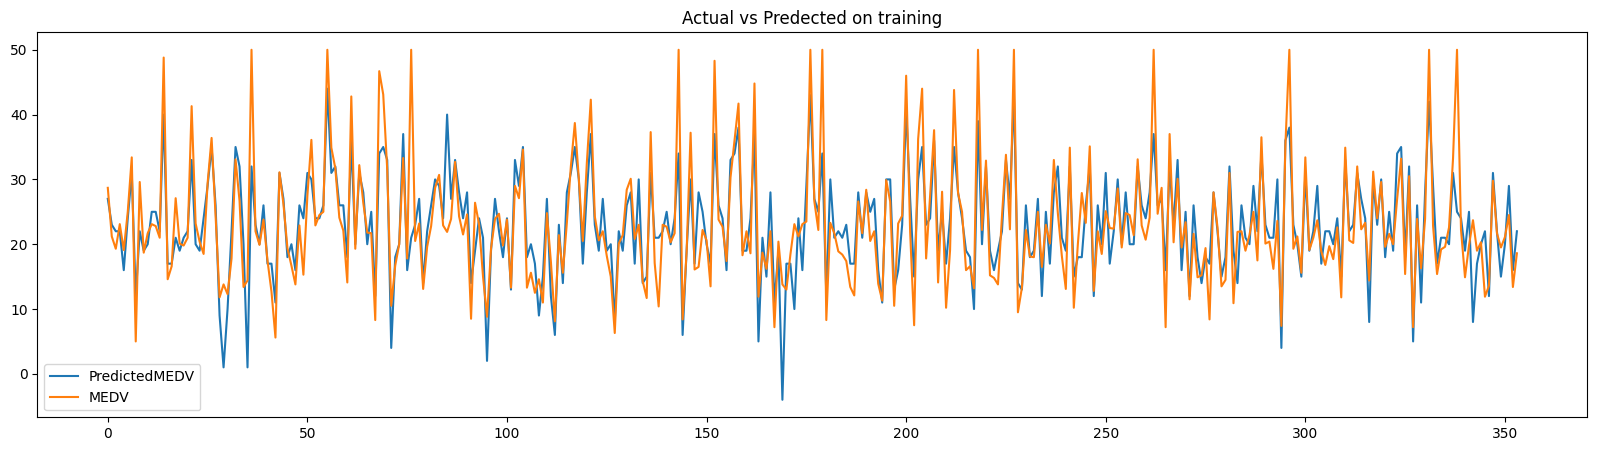

In [ ]:
(TrainingDataResults[['PredictedMEDV','MEDV']]).plot(kind="line",figsize = (20,5),title="Actual vs Predected on training")

<Axes: title={'center': 'Actual vs Predected on training'}>

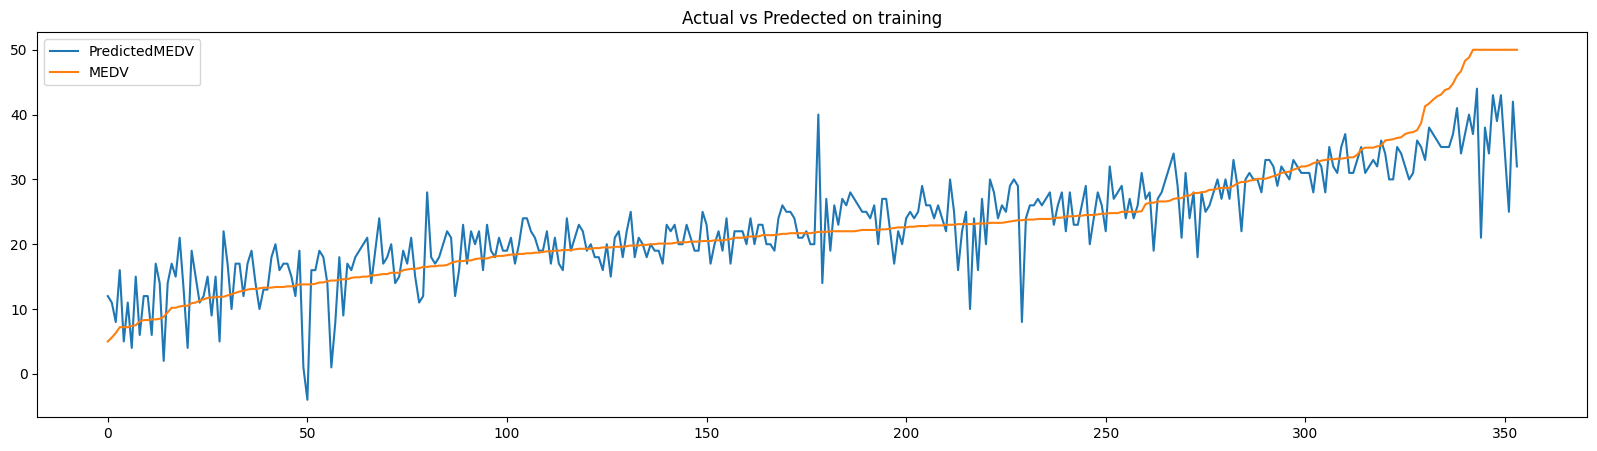

In [ ]:
(TrainingDataResults[['PredictedMEDV','MEDV']].sort_values(by="MEDV").reset_index(drop=True)).plot(kind="line",figsize = (20,5),title="Actual vs Predected on training")

<Axes: title={'center': 'Residual test on training'}>

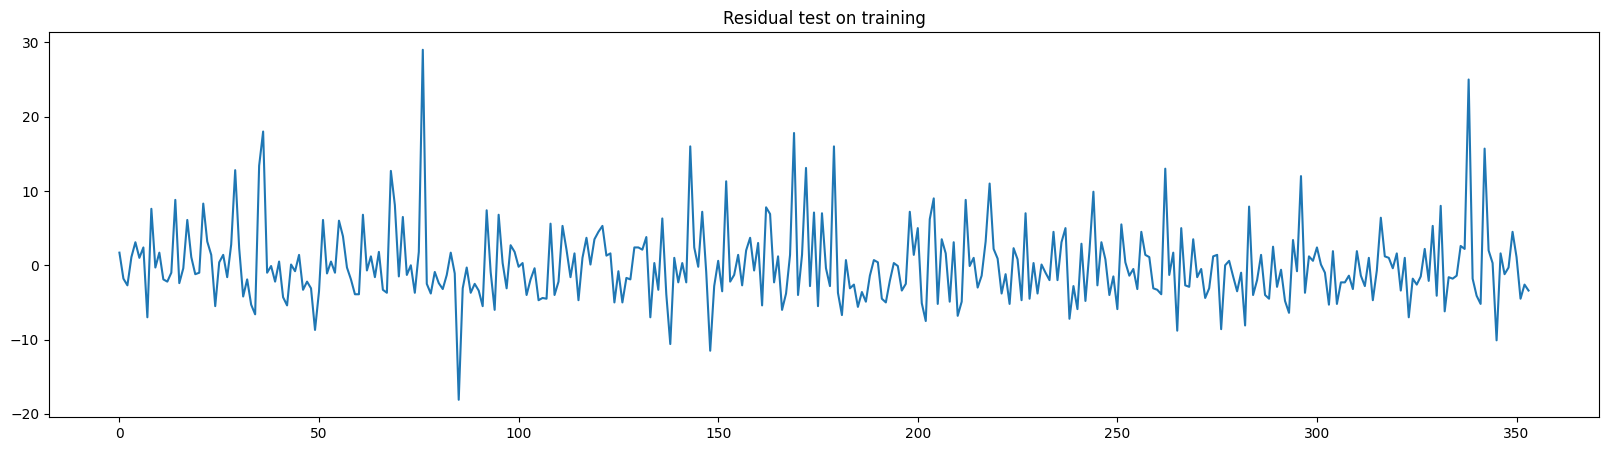

In [ ]:
(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']).plot(kind="line",figsize = (20,5),title="Residual test on training")

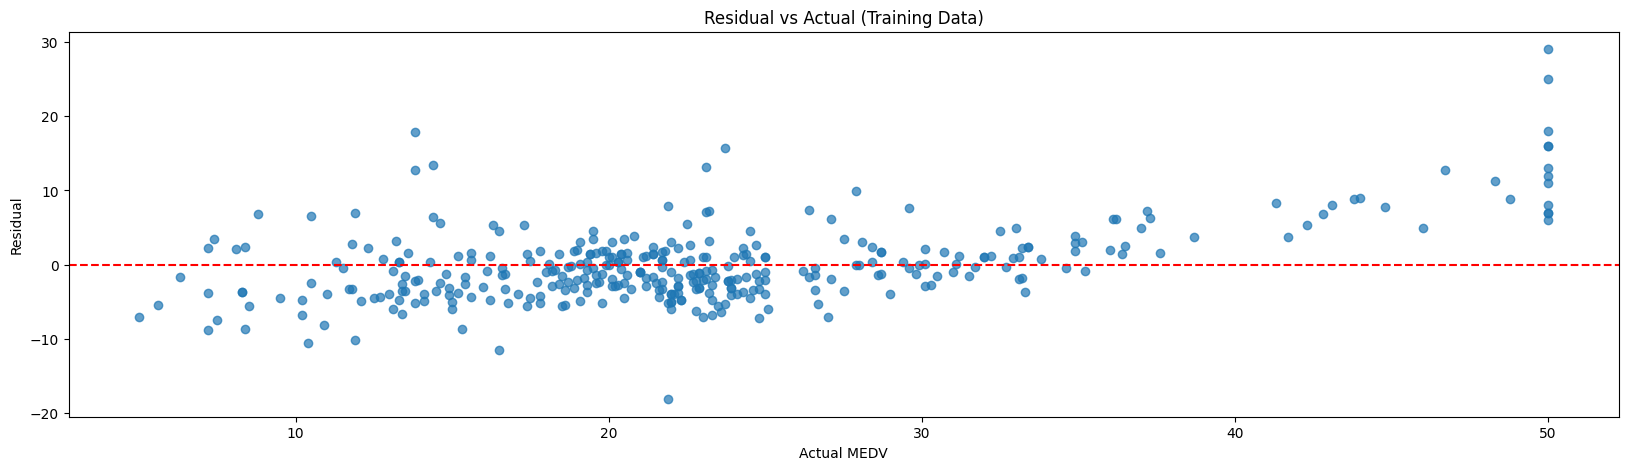

In [ ]:
import matplotlib.pyplot as plt

# คำนวณ residual
residual = TrainingDataResults['MEDV'] - TrainingDataResults['PredictedMEDV']

# สร้าง scatter plot เพื่อแสดงความสัมพันธ์ระหว่าง residual กับค่าจริง
plt.figure(figsize=(20, 5))
plt.scatter(TrainingDataResults['MEDV'], residual, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # เส้นแกน y=0 เพื่อให้เห็น residual ที่ศูนย์
plt.title('Residual vs Actual (Training Data)')
plt.xlabel('Actual MEDV')
plt.ylabel('Residual')
plt.show()

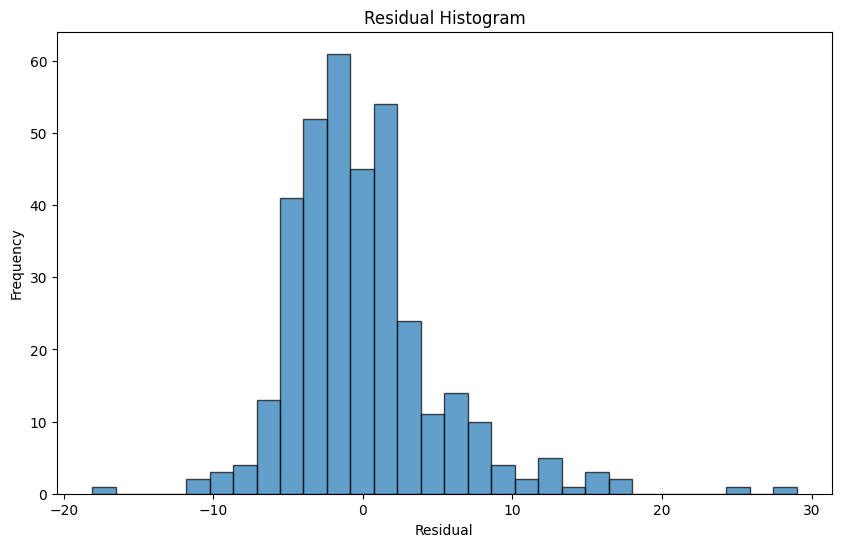

In [ ]:
# สร้าง histogram ของ residual
plt.figure(figsize=(10, 6))
plt.hist(residual, bins=30, edgecolor='black', alpha=0.7)
plt.title('Residual Histogram')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

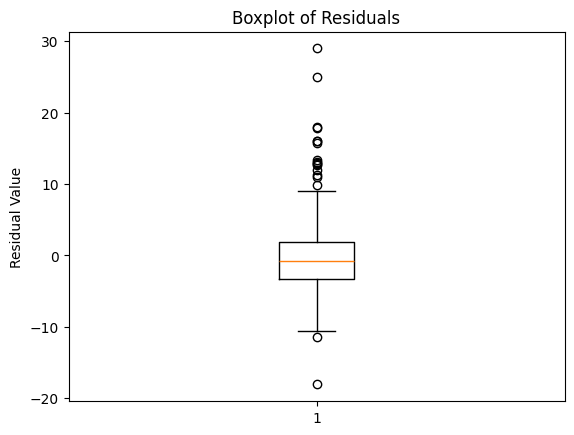

In [ ]:
import matplotlib.pyplot as plt

# Boxplot ของ residual
plt.boxplot(residual)
plt.title("Boxplot of Residuals")
plt.ylabel("Residual Value")
plt.show()

In [ ]:
residual.describe()

,0
count,354.000000
mean,0.001695
std,5.179897
min,-18.100000
25%,-3.275000
50%,-0.850000
75%,1.900000
max,29.000000


In [ ]:
residual.median()

-0.8499999999999996

<Axes: title={'center': 'Actual vs Predected on testing'}>

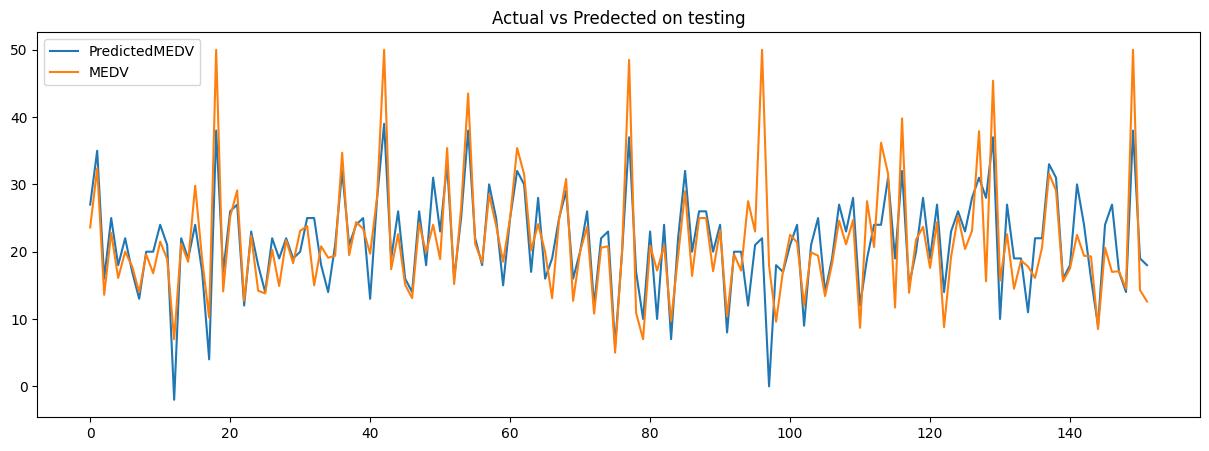

In [ ]:
TestingDataResults[['PredictedMEDV','MEDV']].plot(kind="line",figsize = (15,5),title="Actual vs Predected on testing")

<Axes: title={'center': 'Actual vs Predected on training'}>

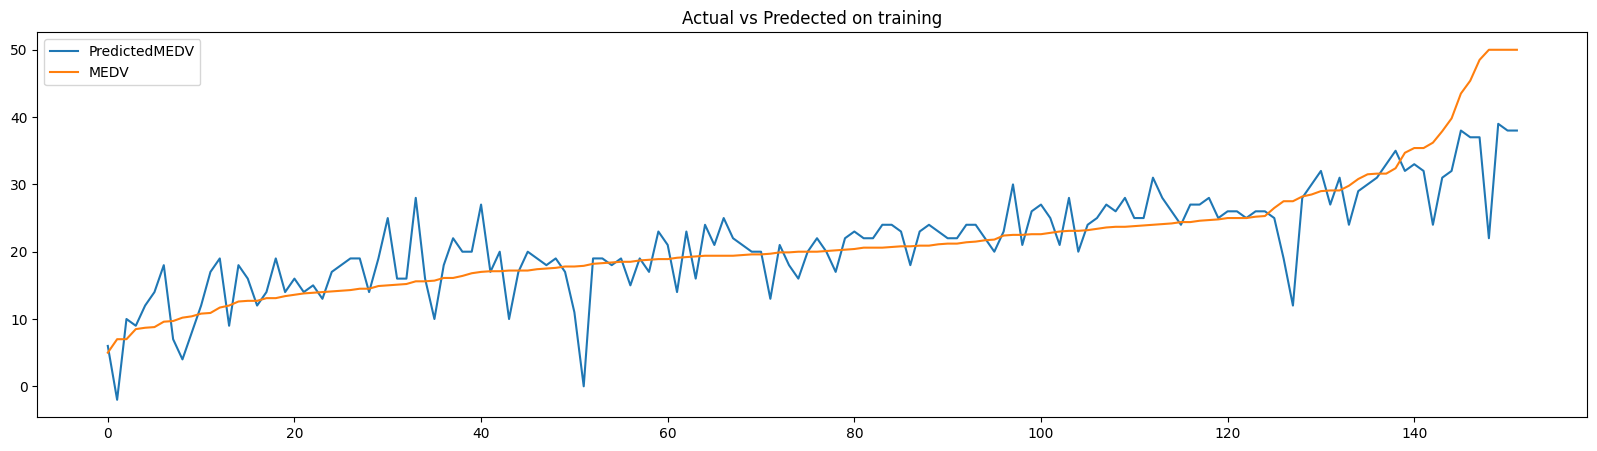

In [ ]:
(TestingDataResults[['PredictedMEDV','MEDV']].sort_values(by="MEDV").reset_index(drop=True)).plot(kind="line",figsize = (20,5),title="Actual vs Predected on training")

<Axes: title={'center': 'Residual test'}>

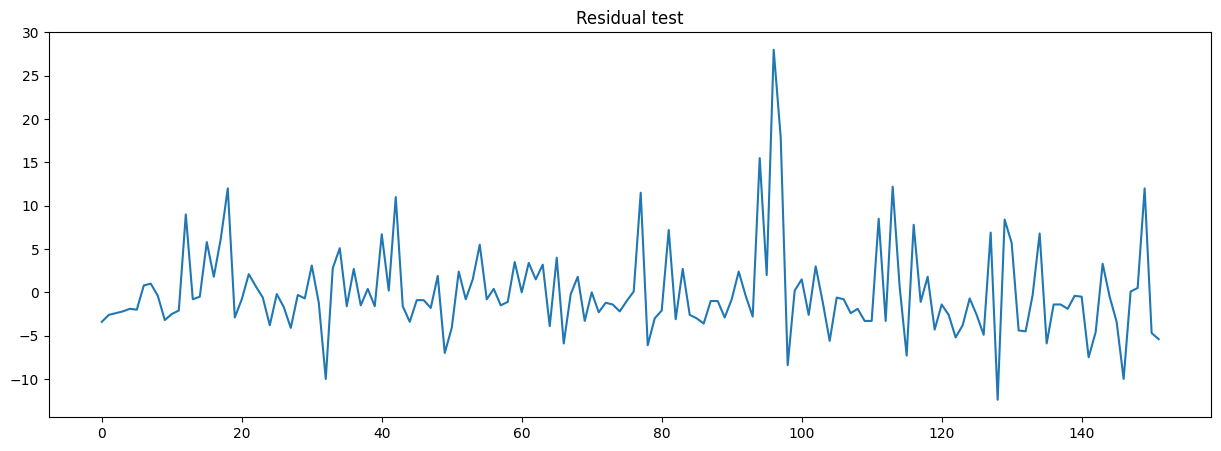

In [ ]:
(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']).plot(kind="line",figsize = (15,5),title="Residual test")

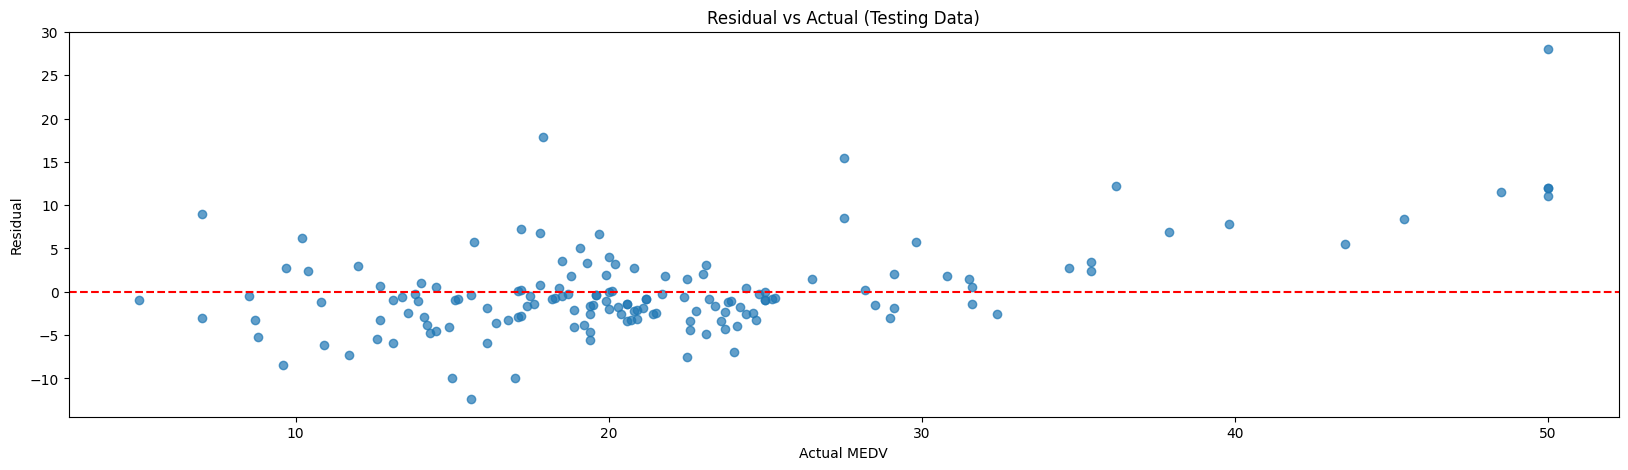

In [ ]:
import matplotlib.pyplot as plt

# คำนวณ residual
residual = TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']

# สร้าง scatter plot เพื่อแสดงความสัมพันธ์ระหว่าง residual กับค่าจริง
plt.figure(figsize=(20, 5))
plt.scatter(TestingDataResults['MEDV'], residual, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # เส้นแกน y=0 เพื่อให้เห็น residual ที่ศูนย์
plt.title('Residual vs Actual (Testing Data)')
plt.xlabel('Actual MEDV')
plt.ylabel('Residual')
plt.show()

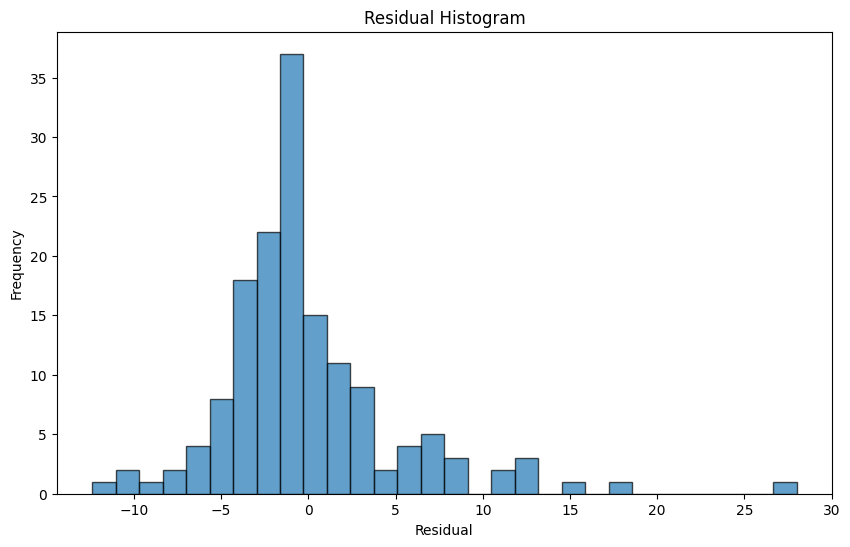

In [ ]:
# สร้าง histogram ของ residual
plt.figure(figsize=(10, 6))
plt.hist(residual, bins=30, edgecolor='black', alpha=0.7)
plt.title('Residual Histogram')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

## **11.2 Decision Trees**

DecisionTreeRegressor(criterion='absolute_error', max_depth=5)
****************************************************************************************************

Training result prediction
         RM   PTRATIO     LSTAT       RAD  CHAS  MEDV  PredictedMEDV
0  0.549722  0.648936  0.096026  0.086957   0.0  28.7           23.0
1  0.501054  0.553191  0.284492  0.217391   0.0  21.2           21.0
2  0.406400  0.563830  0.233996  0.086957   0.0  19.3           21.0
3  0.454876  0.893617  0.133830  0.130435   0.0  23.1           23.0
4  0.453152  0.808511  0.452539  1.000000   0.0  19.1           15.0
****************************************************************************************************

Testing result prediction
         RM   PTRATIO     LSTAT       RAD  CHAS  MEDV  PredictedMEDV
0  0.547040  0.425532  0.201711  0.173913   0.0  23.6           23.0
1  0.612569  0.531915  0.049669  0.130435   1.0  32.4           27.0
2  0.464074  0.797872  0.450883  0.130435   0.0  13.6      

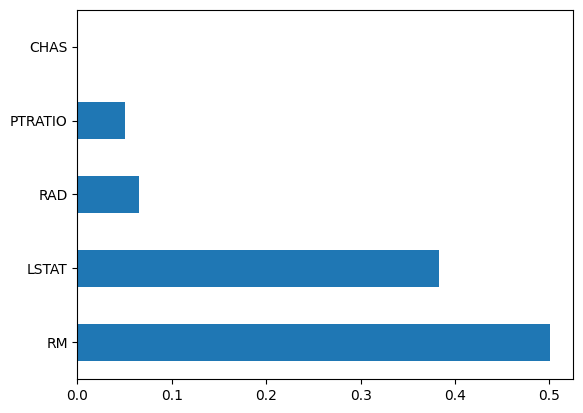

In [ ]:
# Decision Trees (Multiple if-else statements!)
from sklearn.tree import DecisionTreeRegressor
RegModel = DecisionTreeRegressor(max_depth=5,criterion='absolute_error')
# Good Range of Max_depth = 2 to 20
# Or you can find best hyperparameters using GridSearchCV

# Printing all the parameters of Decision Tree
print(RegModel)
print("*"*100)
print()

# Creating the model on Training Data
DT=RegModel.fit(X_train,y_train)

# Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(DT.feature_importances_, index=Predictors)
feature_importances.nlargest(10).plot(kind='barh')

# Printing some sample values of prediction
print("Training result prediction")
TrainingPrediction=DT.predict(X_train)
TrainingDataResults=pd.DataFrame(data=X_train, columns=Predictors)
TrainingDataResults[TargetVariable]=y_train
TrainingDataResults[('Predicted'+TargetVariable)]=np.round(TrainingPrediction)

# Printing sample prediction values
print(TrainingDataResults.head())
print("*"*100)
print()

# Printing some sample values of prediction
print("Testing result prediction")
TestingPrediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(TestingPrediction)

# Printing sample prediction values
print(TestingDataResults.head())
print("*"*100)
print()

from sklearn import metrics
# Measuring Goodness of fit by R square
print('R2 Value of training set:',metrics.r2_score(y_train, LREG.predict(X_train)))
print('R2 Value of testing set:',metrics.r2_score(y_test, LREG.predict(X_test)))

#Measuring Goodness of fit by MAPE
TrainingDataResults['APE']=100 * ((abs(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']))/TrainingDataResults['MEDV'])
MAPE_training=np.mean(TrainingDataResults['APE'])
TestingDataResults['APE']=100 * ((abs(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']))/TestingDataResults['MEDV'])
MAPE_teating=np.mean(TestingDataResults['APE'])
print('MAPE on training data:', MAPE_training)
print('MAPE on test data:', MAPE_teating)
print('Accuracy on training data:', 100-MAPE_training)
print('Accuracy on test data:', 100-MAPE_teating)



**Note:** You should also measure model performance with other matrices such as RMSE, MAE, etc.

In [ ]:
#Vitualization
from sklearn.tree import export_text
print(export_text(DT,feature_names=['RM', 'PTRATIO','LSTAT', 'RAD', 'CHAS']))

|--- RM <= 0.62
|   |--- LSTAT <= 0.40
|   |   |--- LSTAT <= 0.22
|   |   |   |--- RAD <= 0.65
|   |   |   |   |--- RM <= 0.57
|   |   |   |   |   |--- value: [22.95]
|   |   |   |   |--- RM >  0.57
|   |   |   |   |   |--- value: [27.10]
|   |   |   |--- RAD >  0.65
|   |   |   |   |--- RM <= 0.36
|   |   |   |   |   |--- value: [50.00]
|   |   |   |   |--- RM >  0.36
|   |   |   |   |   |--- value: [50.00]
|   |   |--- LSTAT >  0.22
|   |   |   |--- LSTAT <= 0.35
|   |   |   |   |--- PTRATIO <= 0.44
|   |   |   |   |   |--- value: [22.65]
|   |   |   |   |--- PTRATIO >  0.44
|   |   |   |   |   |--- value: [20.65]
|   |   |   |--- LSTAT >  0.35
|   |   |   |   |--- PTRATIO <= 0.70
|   |   |   |   |   |--- value: [20.35]
|   |   |   |   |--- PTRATIO >  0.70
|   |   |   |   |   |--- value: [17.60]
|   |--- LSTAT >  0.40
|   |   |--- LSTAT <= 0.48
|   |   |   |--- PTRATIO <= 0.75
|   |   |   |   |--- PTRATIO <= 0.25
|   |   |   |   |   |--- value: [14.35]
|   |   |   |   |--- PTRATIO > 

<Axes: title={'center': 'Actual vs Predected on training'}>

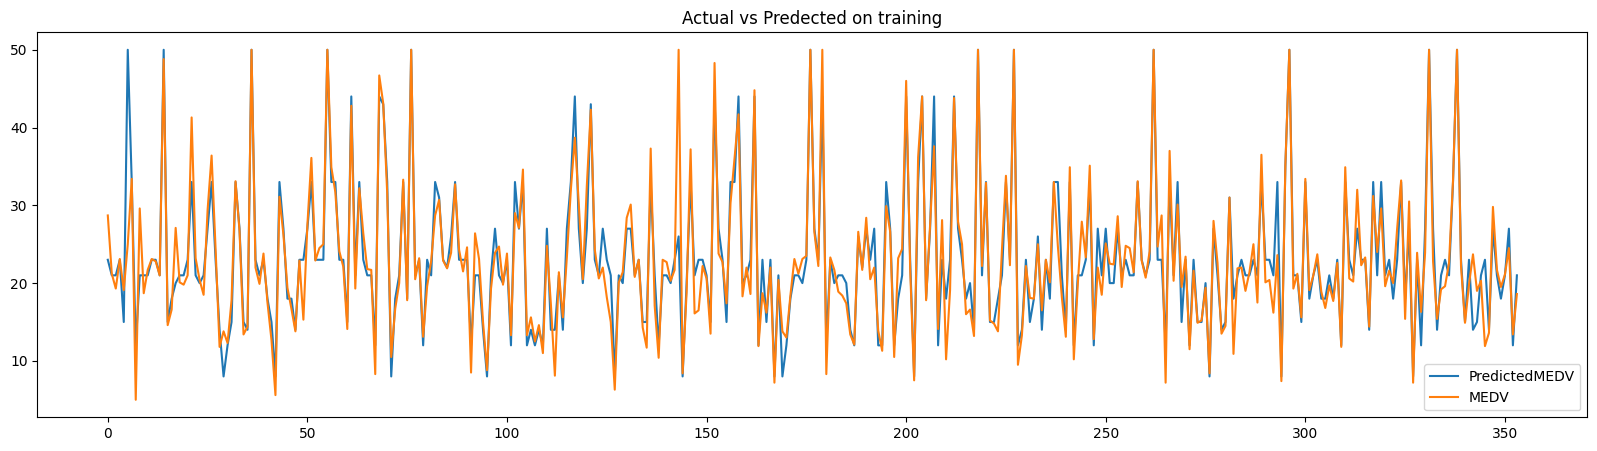

In [ ]:
TrainingDataResults[['PredictedMEDV','MEDV']].plot(kind="line",figsize = (20,5),title="Actual vs Predected on training")

<Axes: title={'center': 'Residual test on training'}>

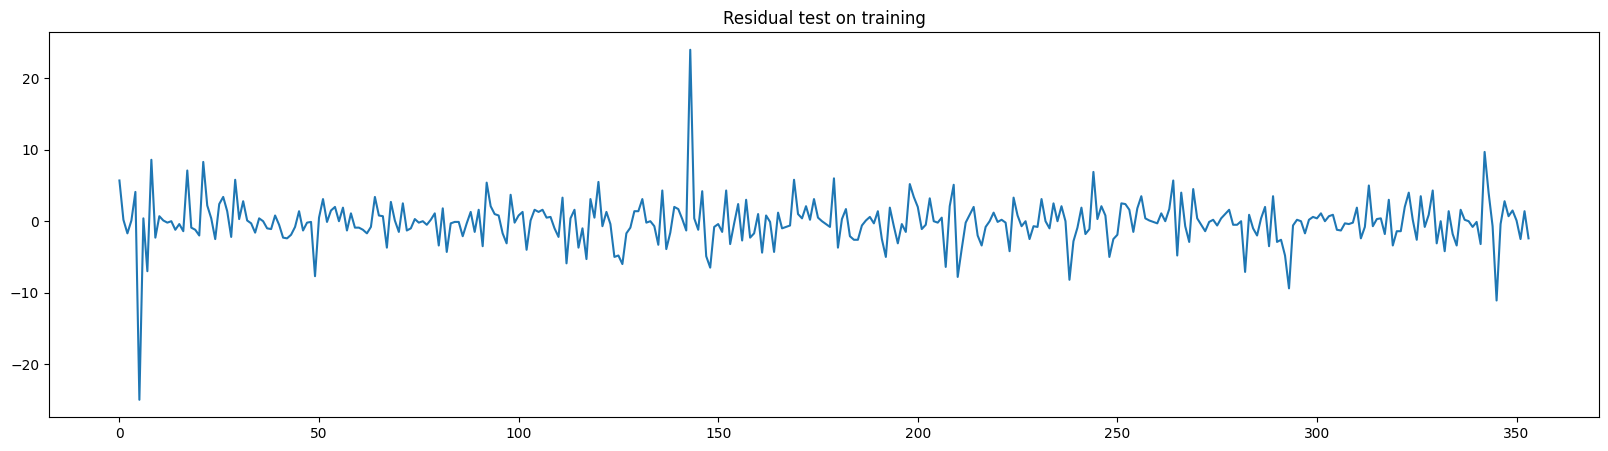

In [ ]:
(TrainingDataResults['MEDV']-TrainingDataResults['PredictedMEDV']).plot(kind="line",figsize = (20,5),title="Residual test on training")

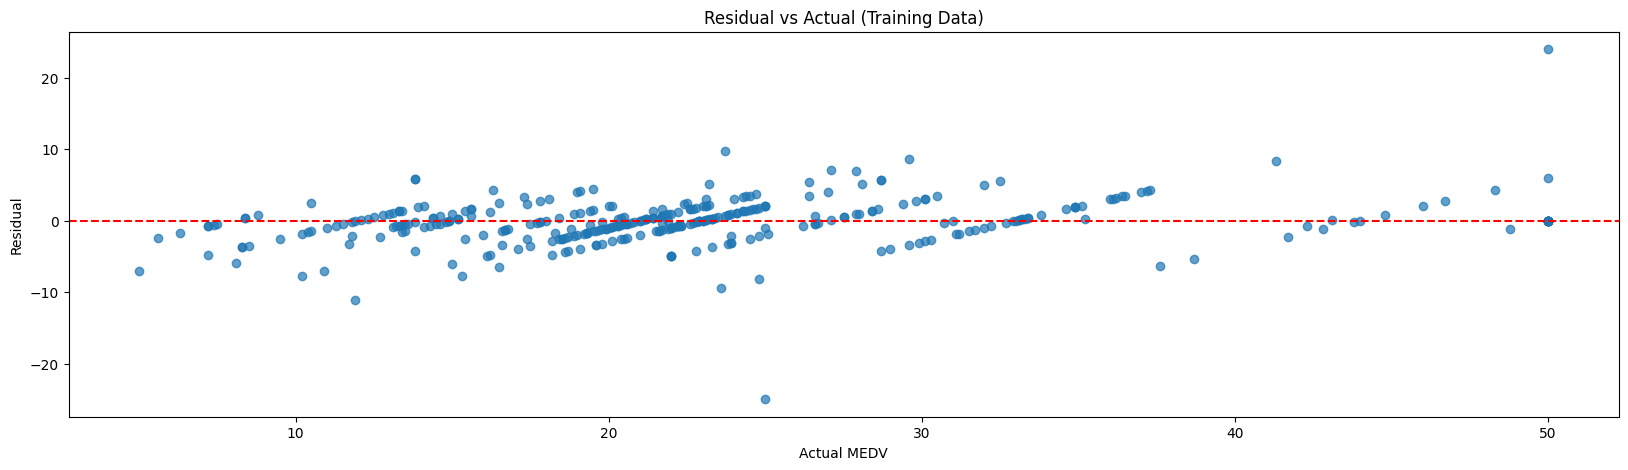

In [ ]:
import matplotlib.pyplot as plt

# คำนวณ residual
residual = TrainingDataResults['MEDV'] - TrainingDataResults['PredictedMEDV']

# สร้าง scatter plot เพื่อแสดงความสัมพันธ์ระหว่าง residual กับค่าจริง
plt.figure(figsize=(20, 5))
plt.scatter(TrainingDataResults['MEDV'], residual, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # เส้นแกน y=0 เพื่อให้เห็น residual ที่ศูนย์
plt.title('Residual vs Actual (Training Data)')
plt.xlabel('Actual MEDV')
plt.ylabel('Residual')
plt.show()

<Axes: title={'center': 'Actual vs Predected on testing'}>

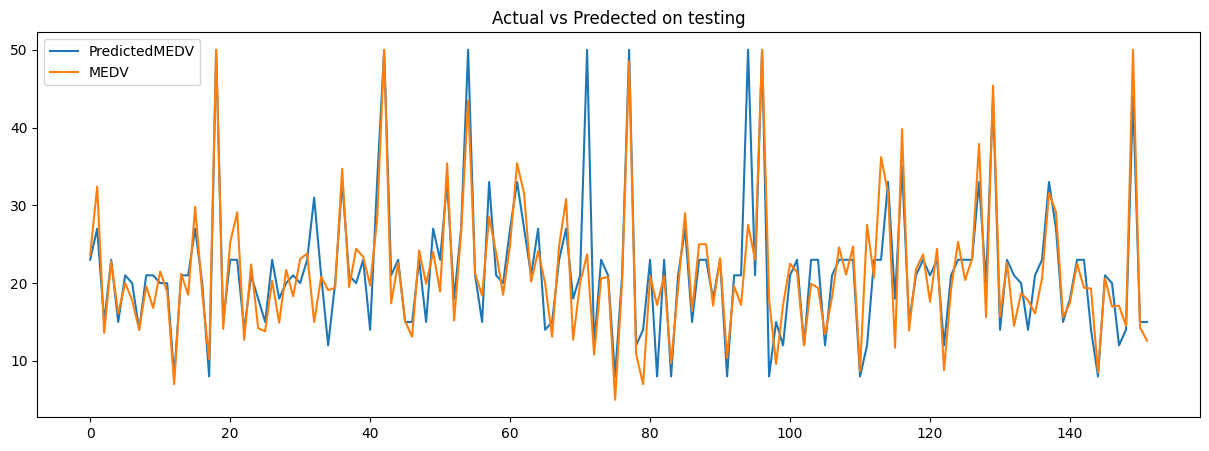

In [ ]:
TestingDataResults[['PredictedMEDV','MEDV']].plot(kind="line",figsize = (15,5),title="Actual vs Predected on testing")

<Axes: title={'center': 'Residual test on testing'}>

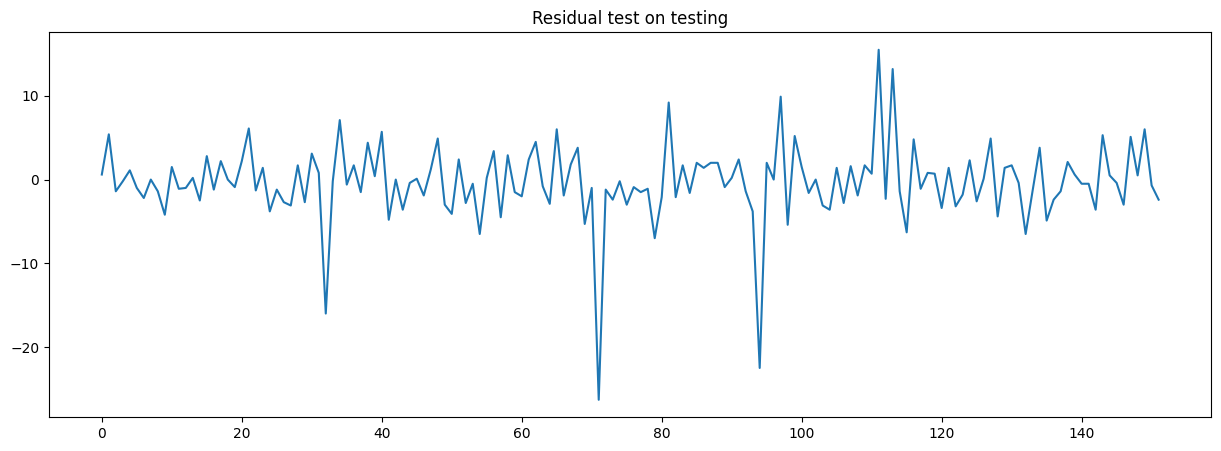

In [ ]:
(TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']).plot(kind="line",figsize = (15,5),title="Residual test on testing")

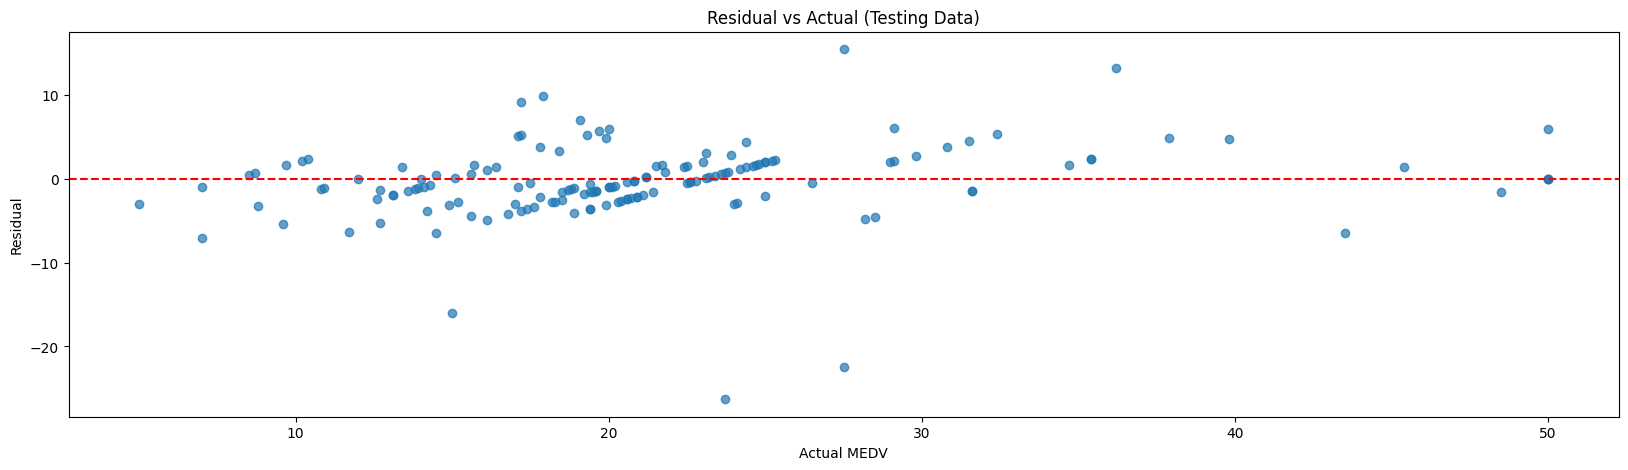

In [ ]:
import matplotlib.pyplot as plt

# คำนวณ residual
residual = TestingDataResults['MEDV']-TestingDataResults['PredictedMEDV']

# สร้าง scatter plot เพื่อแสดงความสัมพันธ์ระหว่าง residual กับค่าจริง
plt.figure(figsize=(20, 5))
plt.scatter(TestingDataResults['MEDV'], residual, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # เส้นแกน y=0 เพื่อให้เห็น residual ที่ศูนย์
plt.title('Residual vs Actual (Testing Data)')
plt.xlabel('Actual MEDV')
plt.ylabel('Residual')
plt.show()

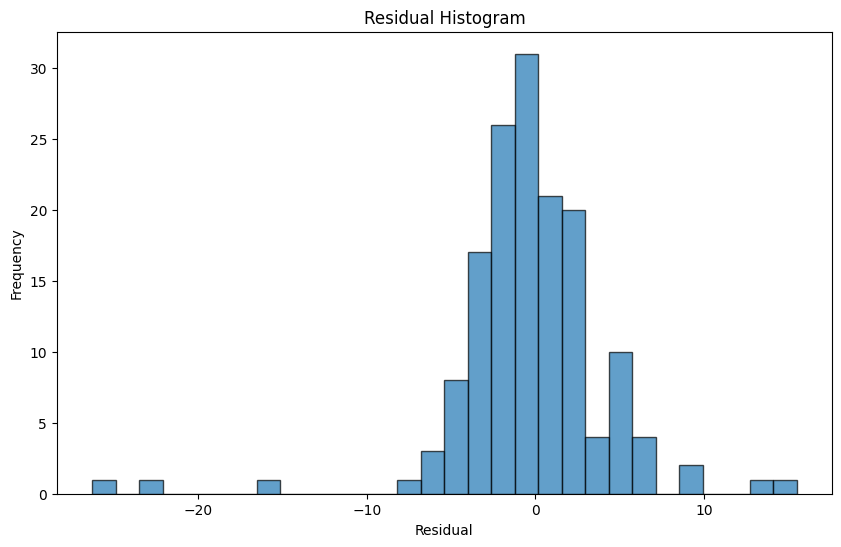

In [ ]:
# สร้าง histogram ของ residual
plt.figure(figsize=(10, 6))
plt.hist(residual, bins=30, edgecolor='black', alpha=0.7)
plt.title('Residual Histogram')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# **12. Results Analysis**

**Guidelines**

Analyzing the prediction results of your ML models, you should analyze the following aspects:
* Overfitting or not? Why?
* How accurate is each model? and which model gives the most accuracy? Why? (Analysis via characteristics of the data and the ML model)
* Based on the accuracy you get from the model, can your model actually be used in real situation?
* What features are important and sufficient to create a ML model that has the highest accuracy?
* If you compare the model performance by setting data transformation or eliminating outliers in doubt predictors, you should be able to tell that this setting affect the model's performance or not?
*  From residual or error analysis, what characteristics of the data make your model less effective?  What is the limitation? (optional but necessary to apply the model in real situation)